In [183]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
###### the spreading of failures
import sys
import pickle,itertools
import requests, json
import copy
import os

import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pypsa
import matplotlib.colors as mplcolors
from tqdm import tqdm

#date_string = datetime.datetime.now().strftime("%I_%M_%B_%d")

path = '/media/fkaiser/'

sys.path.append(path+'Code/power-system-split/power_system_split/')
import utils,visualisation

In [429]:
co2l = 0.05
network = pypsa.Network()
network.import_from_netcdf(path_to_pypsa_network+f'elec_s_800_ec_lv1.0_Co2L{co2l}-3H.nc') 

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.05-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


In [430]:
pypsa_network = network
load_shedding_indices = pypsa_network.generators[pypsa_network.generators.carrier.isin(['load'])].index

loadimba = np.zeros(len(network.snapshots))
for count,timestamp in enumerate(network.snapshots):
    current_generation = pypsa_network.generators_t.p.loc[timestamp].copy()
    current_generation[load_shedding_indices] /= 1e3
    current_storage    = pypsa_network.storage_units_t.p.loc[timestamp]
    current_load       = pypsa_network.loads_t.p.loc[timestamp]
    #assert np.abs(current_generation.sum()+current_storage.sum()-current_load.sum())<5e-2
    loadimba[count] = np.abs(current_generation.sum()+current_storage.sum()-current_load.sum())

In [433]:
loadimba[loadimba > 5e-2]
print(np.max(loadimba))

0.1306885606609285


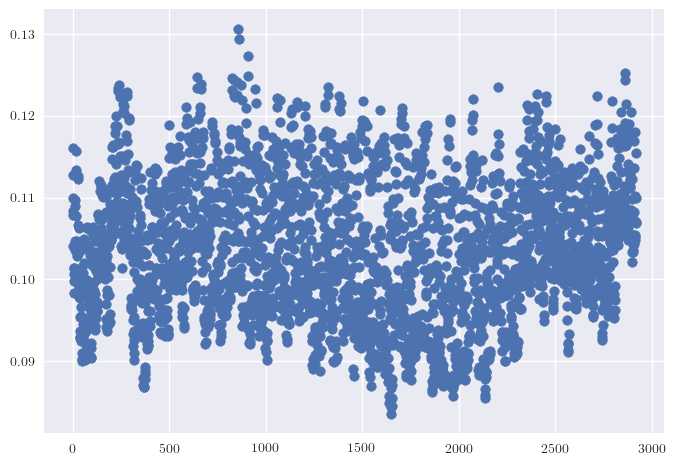

In [431]:
plt.scatter(np.arange(loadimba.shape[0]),loadimba)

# Run cascades for European grid

In [185]:
path_to_pypsa_network   = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/'

co2l = 0.2

network = pypsa.Network()
network.import_from_netcdf(path_to_pypsa_network+'elec_s_800_ec_lv1.0_Co2L%.1f-3H.nc'%co2l) # +year+'/elec_s_306_ec_lv1.0_1H.nc')#

snet_index = 0

G = utils.build_networkx_graph(network, snet_index = snet_index)

indices = nx.get_edge_attributes(G, 'line_index')
line_limits = nx.get_edge_attributes(G, 's_nom')

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.2-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


In [15]:
current_month = 3

current_snapshots = network.snapshots[network.snapshots.month == current_month]

indices = nx.get_edge_attributes(G, 'line_index')
line_limits = nx.get_edge_attributes(G, 's_nom')

### iterate only over non-bridge edges for now
bridges = list(nx.bridges(nx.Graph(G)))

non_bridges = list(set(list(G.edges())) - set(bridges))

splitting_cascades = {}

for snapshot in tqdm(current_snapshots):

    splitting_cascades[snapshot.strftime('%d_%m_%Y_%H')] = []

    initial_loading = {e: np.sum([network.lines_t.p0.loc[snapshot].loc[index] for index in index_list]) for
                       e, index_list in indices.items()}
    P0 = utils.get_effective_injections(G, initial_loading)

    l_copy = initial_loading.copy()
    for key in l_copy.keys():
        initial_loading[key[::-1]] = initial_loading[key]

    for edge in non_bridges:

        failing_links, system_split = utils.simulate_cascade_PTDF_based_edge_based_reduced(G,
                                                                                           trigger_links=[edge],
                                                                                           line_limits=line_limits,
                                                                                           P0=P0)
        if system_split:
            splitting_cascades[snapshot.strftime('%d_%m_%Y_%H')].append(failing_links)



  0%|          | 1/248 [00:17<1:10:21, 17.09s/it]


KeyboardInterrupt: 

In [8]:
save_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/Results/'

with open(save_path + 'system_splits_%i_Co2L%.1f.pickle' % (current_month, co2l), 'wb') as handle:
    pickle.dump(splitting_cascades, handle, protocol = pickle.HIGHEST_PROTOCOL)

# Evaluate results for European grid

In [198]:
co2l = 0.5
#current_month = 5

path_to_pypsa_network   = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/'
results_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/Results/'

network = pypsa.Network()
network.import_from_netcdf(path_to_pypsa_network+'elec_s_800_ec_lv1.0_Co2L%.1f-3H.nc'%co2l) # +year+'/elec_s_306_ec_lv1.0_1H.nc')#

snet_index = 0

G = utils.build_networkx_graph(network, snet_index = snet_index)

indices = nx.get_edge_attributes(G, 'line_index')
line_limits = nx.get_edge_attributes(G, 's_nom')

use_pnom  = True
criterion = 'nodes'

splitting_cascades = pickle.load(open(results_path+'system_splits_Co2L%.1f.pickle' % ( co2l),'rb'))
                                      #'system_splits_%i_Co2L%.1f.pickle' % (current_month, co2l),'rb'))

solution_dict = {}

for key in tqdm(splitting_cascades.keys()):
    timestamp = utils.solution_key_to_pandas_timestamp(key)
    solution_dict[key] = []
    splits = splitting_cascades[key]
    print(key)
    for i,split in enumerate(splits):
        results = utils.evaluate_split_observables(split,
                                                   network,
                                                   timestamp,
                                                   use_pnom = use_pnom,
                                                   criterion = criterion,
                                                  snet_index = snet_index)
        if results['inertia_proxy']:
            solution_dict[key].append(i)
            solution_dict[key].append(results)


/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.5-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
  0%|          | 0/2920 [00:00<?, ?it/s]

01_04_2013_00


  0%|          | 1/2920 [00:24<19:43:23, 24.32s/it]

01_04_2013_03


  0%|          | 2/2920 [00:50<20:29:42, 25.29s/it]

...

09_04_2013_18


  2%|▏         | 71/2920 [42:29<32:54:27, 41.58s/it]

09_04_2013_21


  2%|▏         | 71/2920 [43:02<28:47:25, 36.38s/it]


KeyboardInterrupt: 

In [296]:
nx_graph = G
list_of_nodes = list(nx_graph)
n_nodes = len(list_of_nodes)

indicator_vectors = np.empty((0, n_nodes), bool)

columns = ["time_stamp","number_of_split","inertia_proxy","load_imbalance",
                                              "available_flexible_generation"]

split_component_props =  []#pd.DataFrame(columns = columns)

counter = 0
for time_stamp in list(solution_dict.keys()):
    
    if not solution_dict[time_stamp]:
        continue
    
    for i, split_number in enumerate(solution_dict[time_stamp][::2]):

        split = splitting_cascades[time_stamp][split_number]
        components = utils.get_split_components(split, nx_graph, criterion = criterion)

        component_props = solution_dict[time_stamp][i*2+1]

        for j, component in enumerate(components):
            component_indicator_vec = np.isin(list_of_nodes, list(component))
            indicator_vectors = np.append(indicator_vectors, np.array([component_indicator_vec]),
                                          axis=0)
      
            props = dict(zip(columns,[time_stamp, 
                     split_number,
                     component_props['inertia_proxy'][j],
                     component_props['load_imbalance'][j],
                     component_props['available_flexible_generation'][j]]))
            split_component_props.append(props)
            counter += 1
split_component_props = pd.DataFrame(split_component_props)

In [297]:
split_component_props

,time_stamp,number_of_split,inertia_proxy,load_imbalance,available_flexible_generation
0,01_04_2013_00,4,147765.279847,-14439.738631,45823.706171
1,01_04_2013_00,4,7958.166258,6102.487064,777.931519
2,01_04_2013_00,17,155723.446104,-16620.797931,46166.661593
3,01_04_2013_00,17,0.000000,7093.490614,434.976098
4,01_04_2013_03,5,152301.638711,-15489.358864,45842.671123
...,...,...,...,...,...
32087,31_12_2013_21,28,0.000000,7902.670353,434.989692
32088,31_12_2013_21,31,145341.760303,-7819.297952,45733.910734
32089,31_12_2013_21,31,0.000000,4242.532132,3570.940202
32090,31_12_2013_21,45,145144.750303,-10501.904624,48252.952818


In [199]:
indicator_vectors, component_props = visualisation.indicator_vectors_from_rocof_solution(solution_dict, 
                                                                                         splitting_cascades, 
                                                                                         G, 
                                                                                         criterion = criterion)

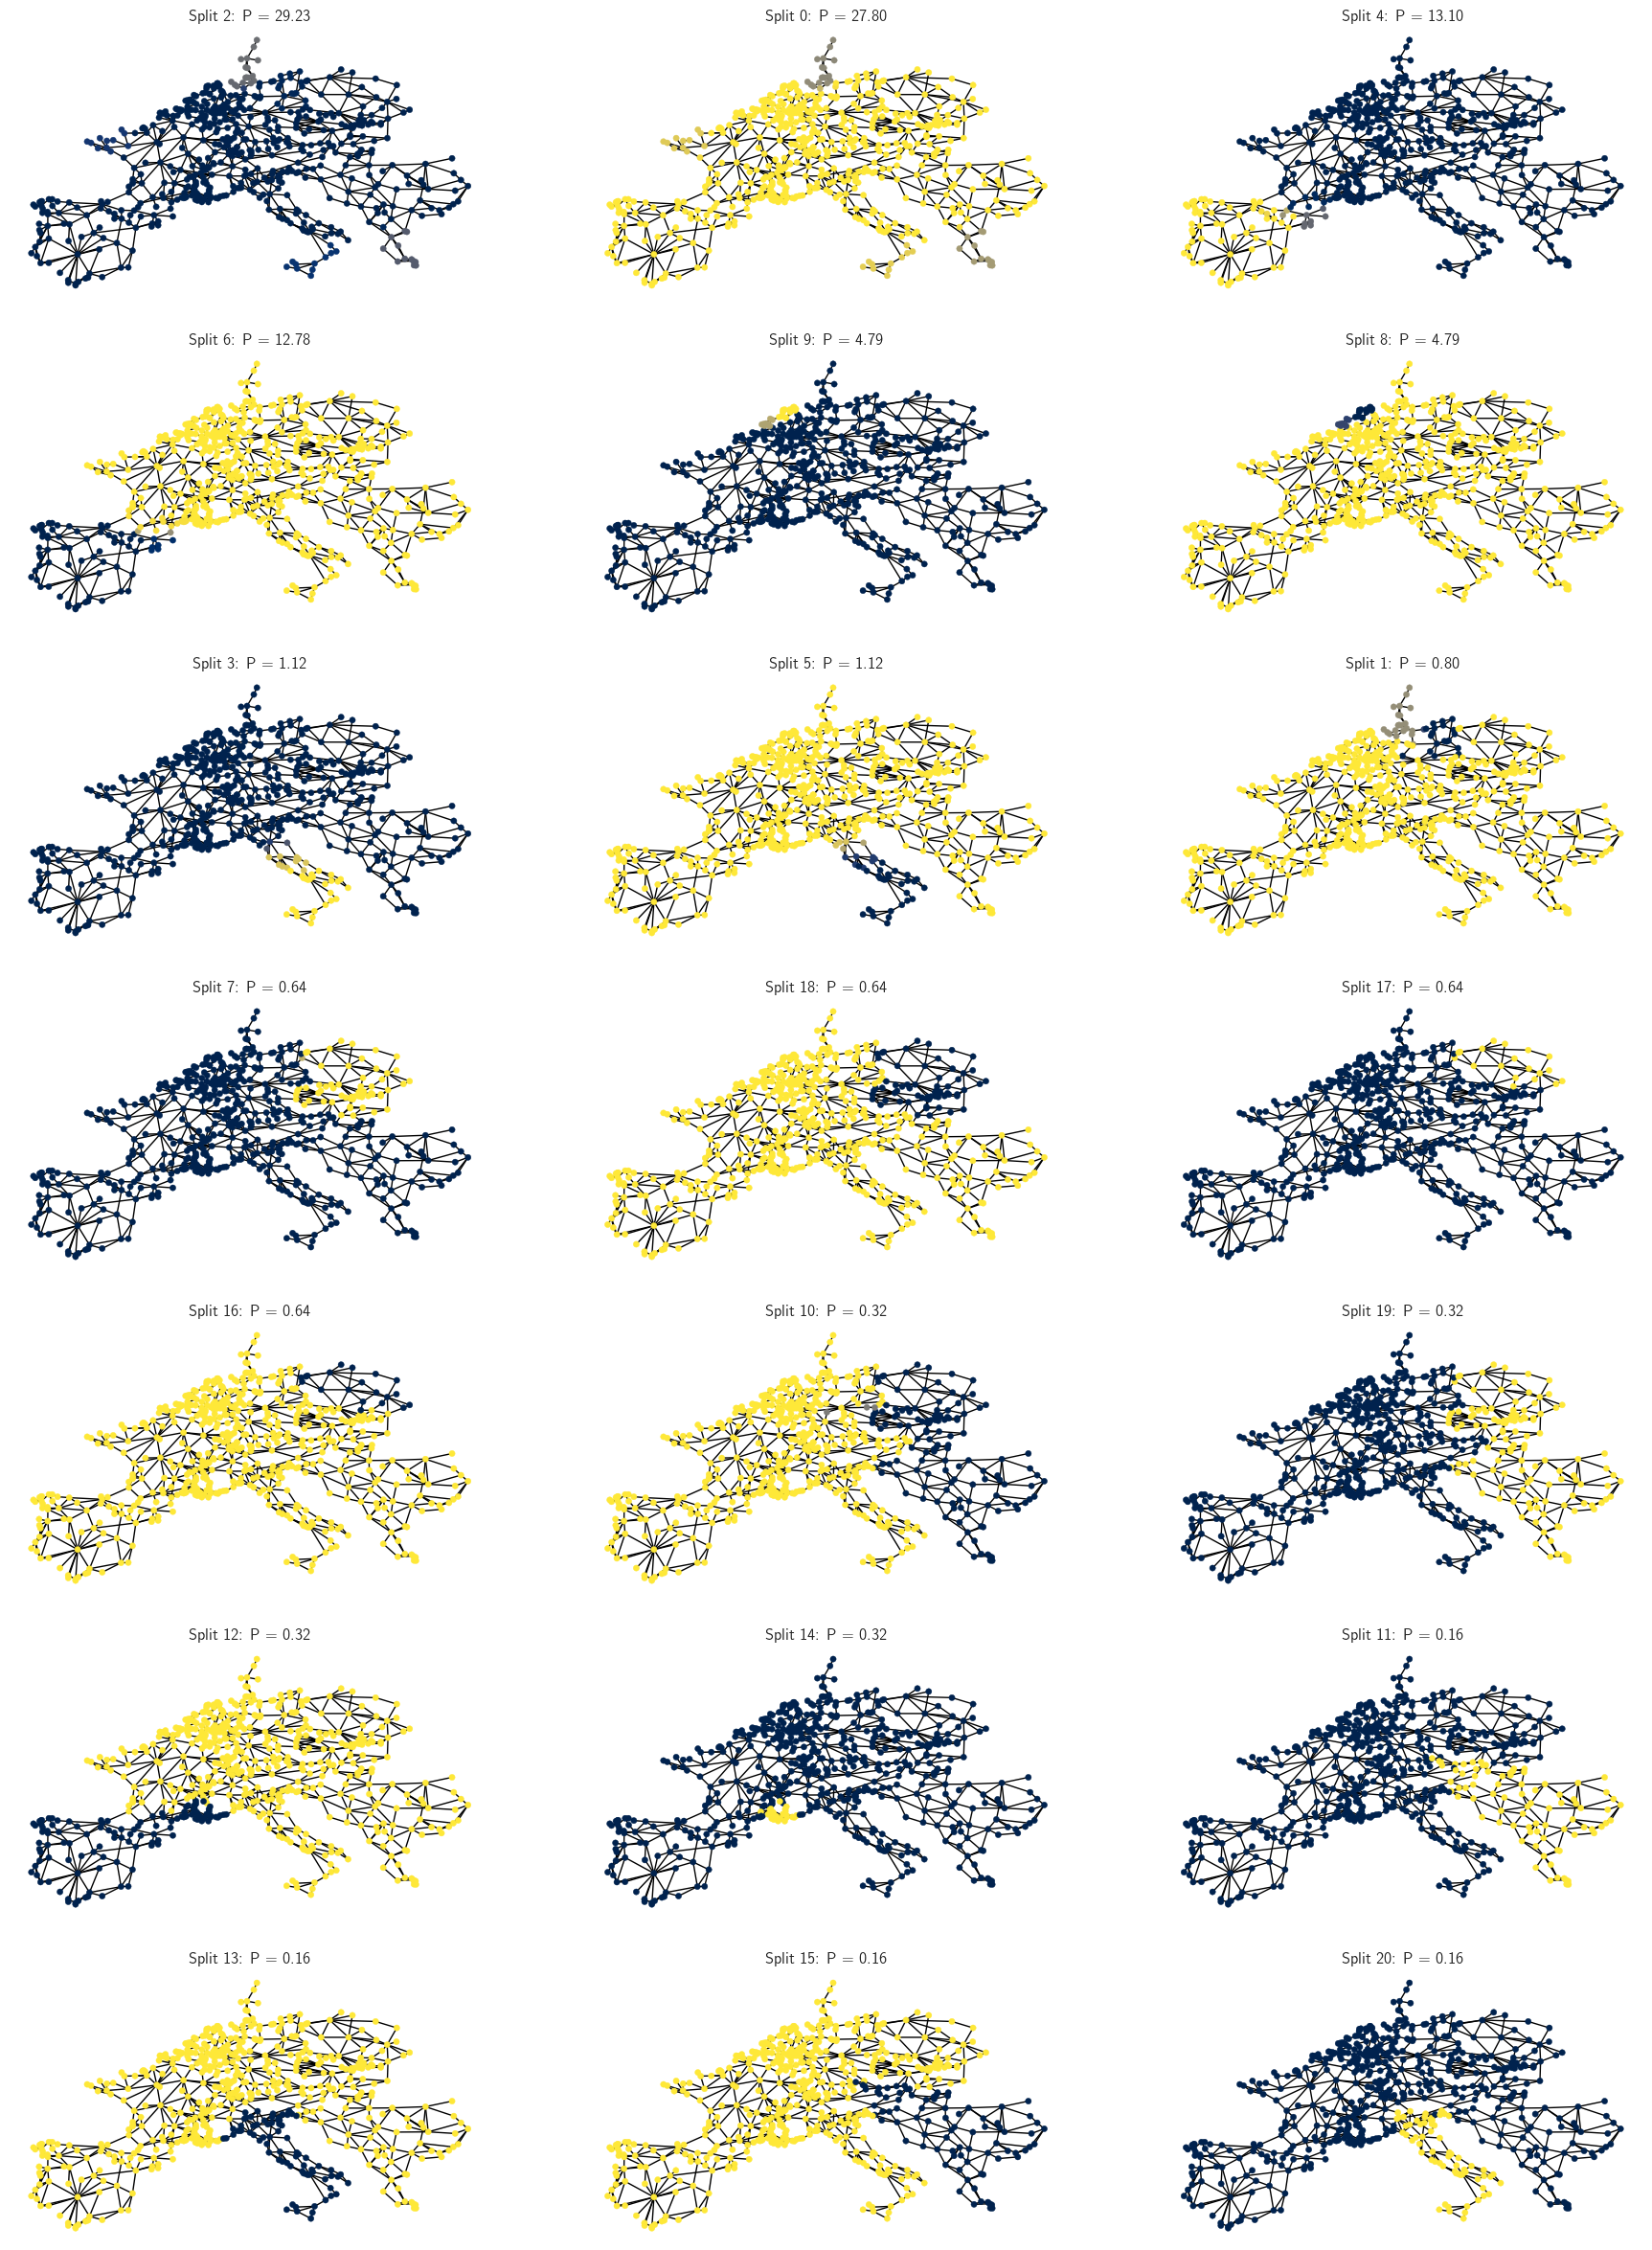

In [201]:
min_cluster_distance = 30./ len(G.nodes())
n_cluster, cluster_labels = visualisation.cluster_indicator_vectors(indicator_vectors, 
                                                                    min_cluster_distance = min_cluster_distance)

n_cols = 3
n_rows = np.ceil(n_cluster/n_cols).astype(int)
fig,ax = plt.subplots(n_rows,n_cols,figsize=(22,30))

visualisation.plot_component_cluster(indicator_vectors, ax.flatten()[:n_cluster],
                                     cluster_labels, G)

In [299]:
print(n_cluster,cluster_labels)
print(len(cluster_labels),indicator_vectors.shape)

21 [16 17  0  2 16 17  0  2  0  2  0  2 16 17  8  9  6  4  0  2  8  9  0  2
  0  2 16 17  0  2  0  2  6  4  0  2  6  4  0  2 18  7  0  2  0  2  8  9
  6  4  6  4  8  9  0  2 18  7  0  2  8  9  8  9  0  2 18  7  0  2  0  2
  6  4  0  2 11 15  0  2  6  4  0  2  0  2  0  2  0  2  0  2  0  2  0  2
  0  2  0  2  6  4  8  9  6  4  8  9  8  9  8  9  6  4  8  9  0  2  6  4
  6  4  8  9  5  3  6  4  6  4  0  2  0  2  0  2  8  9  8  9  6  4  8  9
  0  2  0  2  0  2  0  2  8  9  8  9  0  2  8  9  0  2  6  4  6  4  0  2
  0  2  6  4  0  2  0  2  0  2  6  4  8  9  6  4  0  2  8  9  0  2  8  9
  0  2  8  9  8  9  8  9  0  2  0  2  0  2  0  2  0  2  6  4  6  4  0  2
  0  2  0  2  5  3  5  3  6  4  0  2  0  2  0  2  0  2  0  2  0  2  6  4
  6  4  0  2  0  2  0  2  0  2  6  4  6  4  0  2  0  2  0  2  0  2  0  2
  6  4  6  4 18  7  0  2  8  9  6  4  8  9  0  2  8  9  8  9  8  9  6  4
  8  9  0  2  5  3  0  2  0  2  6  4  6  4  0  2  0  2  0  2  0  2  5  3
  6  4  0  2  0  2  0  2  0  2  0  2  6  4  0  2

In [197]:
bridges = list(nx.bridges(nx.Graph(G)))
non_bridges = list(set(list(G.edges())) - set(bridges))

number_of_simulations = len(non_bridges)*len(solution_dict.keys())

cluster_props = split_component_results.groupby('cluster_label').size().to_frame('counts')
cluster_props.loc[:,'likelihood'] = cluster_props.counts.div(number_of_simulations)
cluster_props.loc[:,'mean_number_of_nodes'] = split_component_results.groupby('cluster_label')['number_of_nodes'].mean()
cluster_props.loc[:,'mean_rocof'] = split_component_results.groupby('cluster_label')['rocof'].mean()
cluster_props

NameError: name 'split_component_results' is not defined

In [32]:
#timestamp = network.snapshots[0]
load_shedding_indices = network.generators[network.generators.carrier.isin(['load'])].index

for timestamp in network.snapshots:

    current_generation = network.generators_t.p.loc[timestamp].copy()
    print(current_generation[load_shedding_indices])
    current_generation[load_shedding_indices] /= 1e3
    current_storage    = network.storage_units_t.p.loc[timestamp]
    current_load       = network.loads_t.p.loc[timestamp]
    
    #try:
    #print(np.abs(current_generation.sum()))
    #print(np.abs(current_storage.sum()))
    #print(np.abs(current_load.sum()))
    
    print(np.abs(current_generation.sum()+current_storage.sum()-current_load.sum()))

Series([], Name: 2013-01-01 00:00:00, dtype: float64)
0.03737901581916958
Series([], Name: 2013-01-01 03:00:00, dtype: float64)
0.037063860916532576
Series([], Name: 2013-01-01 06:00:00, dtype: float64)
0.038254435639828444
Series([], Name: 2013-01-01 09:00:00, dtype: float64)
0.04150021879468113
Series([], Name: 2013-01-01 12:00:00, dtype: float64)
0.039745098911225796
Series([], Name: 2013-01-01 15:00:00, dtype: float64)
0.03501344029791653
Series([], Name: 2013-01-01 18:00:00, dtype: float64)
0.03357174136908725
Series([], Name: 2013-01-01 21:00:00, dtype: float64)
0.0331467377836816
Series([], Name: 2013-01-02 00:00:00, dtype: float64)
0.032762834103778005
Series([], Name: 2013-01-02 03:00:00, dtype: float64)
0.03192984370980412
Series([], Name: 2013-01-02 06:00:00, dtype: float64)
0.033612025959882885
Series([], Name: 2013-01-02 09:00:00, dtype: float64)
0.037716007442213595
Series([], Name: 2013-01-02 12:00:00, dtype: float64)
0.03809305641334504
Series([], Name: 2013-01-02 15:00

Series([], Name: 2013-01-22 09:00:00, dtype: float64)
0.038210852595511824
Series([], Name: 2013-01-22 12:00:00, dtype: float64)
0.03724778536707163
Series([], Name: 2013-01-22 15:00:00, dtype: float64)
0.03399151988560334
Series([], Name: 2013-01-22 18:00:00, dtype: float64)
0.03115782089298591
Series([], Name: 2013-01-22 21:00:00, dtype: float64)
0.0301455813460052
Series([], Name: 2013-01-23 00:00:00, dtype: float64)
0.029586807650048286
Series([], Name: 2013-01-23 03:00:00, dtype: float64)
0.02931971417274326
Series([], Name: 2013-01-23 06:00:00, dtype: float64)
0.0320250490331091
Series([], Name: 2013-01-23 09:00:00, dtype: float64)
0.034843352157622576
Series([], Name: 2013-01-23 12:00:00, dtype: float64)
0.03433297632727772
Series([], Name: 2013-01-23 15:00:00, dtype: float64)
0.0317578986287117
Series([], Name: 2013-01-23 18:00:00, dtype: float64)
0.030069550033658743
Series([], Name: 2013-01-23 21:00:00, dtype: float64)
0.030208950280211866
Series([], Name: 2013-01-24 00:00:00

0.03483394382055849
Series([], Name: 2013-02-10 09:00:00, dtype: float64)
0.03929096844512969
Series([], Name: 2013-02-10 12:00:00, dtype: float64)
0.03977049083914608
Series([], Name: 2013-02-10 15:00:00, dtype: float64)
0.03770086099393666
Series([], Name: 2013-02-10 18:00:00, dtype: float64)
0.035138526756782085
Series([], Name: 2013-02-10 21:00:00, dtype: float64)
0.03539408522192389
Series([], Name: 2013-02-11 00:00:00, dtype: float64)
0.0354421118972823
Series([], Name: 2013-02-11 03:00:00, dtype: float64)
0.03470846376148984
Series([], Name: 2013-02-11 06:00:00, dtype: float64)
0.037912588159088045
Series([], Name: 2013-02-11 09:00:00, dtype: float64)
0.0403115592780523
Series([], Name: 2013-02-11 12:00:00, dtype: float64)
0.04022395919309929
Series([], Name: 2013-02-11 15:00:00, dtype: float64)
0.03751624294091016
Series([], Name: 2013-02-11 18:00:00, dtype: float64)
0.034225494193378836
Series([], Name: 2013-02-11 21:00:00, dtype: float64)
0.03269757179077715
Series([], Name: 

0.03017538844142109
Series([], Name: 2013-02-26 03:00:00, dtype: float64)
0.03026730747660622
Series([], Name: 2013-02-26 06:00:00, dtype: float64)
0.03457238303963095
Series([], Name: 2013-02-26 09:00:00, dtype: float64)
0.03715103823924437
Series([], Name: 2013-02-26 12:00:00, dtype: float64)
0.036155111505649984
Series([], Name: 2013-02-26 15:00:00, dtype: float64)
0.03318663680693135
Series([], Name: 2013-02-26 18:00:00, dtype: float64)
0.029999592865351588
Series([], Name: 2013-02-26 21:00:00, dtype: float64)
0.029260252660606056
Series([], Name: 2013-02-27 00:00:00, dtype: float64)
0.02913526020711288
Series([], Name: 2013-02-27 03:00:00, dtype: float64)
0.029231504595372826
Series([], Name: 2013-02-27 06:00:00, dtype: float64)
0.03352669719606638
Series([], Name: 2013-02-27 09:00:00, dtype: float64)
0.03639374522026628
Series([], Name: 2013-02-27 12:00:00, dtype: float64)
0.036486317578237504
Series([], Name: 2013-02-27 15:00:00, dtype: float64)
0.03411617095116526
Series([], Na

0.03014285519020632
Series([], Name: 2013-03-13 21:00:00, dtype: float64)
0.029463743034284562
Series([], Name: 2013-03-14 00:00:00, dtype: float64)
0.029619514534715563
Series([], Name: 2013-03-14 03:00:00, dtype: float64)
0.030724370386451483
Series([], Name: 2013-03-14 06:00:00, dtype: float64)
0.03581854316871613
Series([], Name: 2013-03-14 09:00:00, dtype: float64)
0.03967208444373682
Series([], Name: 2013-03-14 12:00:00, dtype: float64)
0.03941249253693968
Series([], Name: 2013-03-14 15:00:00, dtype: float64)
0.036718109680805355
Series([], Name: 2013-03-14 18:00:00, dtype: float64)
0.03273404494393617
Series([], Name: 2013-03-14 21:00:00, dtype: float64)
0.03291337040718645
Series([], Name: 2013-03-15 00:00:00, dtype: float64)
0.032945569953881204
Series([], Name: 2013-03-15 03:00:00, dtype: float64)
0.03378451202297583
Series([], Name: 2013-03-15 06:00:00, dtype: float64)
0.03908202861202881
Series([], Name: 2013-03-15 09:00:00, dtype: float64)
0.04405168700031936
Series([], Na

...

Series([], Name: 2013-10-21 06:00:00, dtype: float64)
0.0376154332770966
Series([], Name: 2013-10-21 09:00:00, dtype: float64)
0.04078064073109999
Series([], Name: 2013-10-21 12:00:00, dtype: float64)
0.03936765651451424
Series([], Name: 2013-10-21 15:00:00, dtype: float64)
0.036529550270643085
Series([], Name: 2013-10-21 18:00:00, dtype: float64)
0.033896355889737606
Series([], Name: 2013-10-21 21:00:00, dtype: float64)
0.03450473502743989
Series([], Name: 2013-10-22 00:00:00, dtype: float64)
0.03494453488383442
Series([], Name: 2013-10-22 03:00:00, dtype: float64)
0.035688954521901906
Series([], Name: 2013-10-22 06:00:00, dtype: float64)
0.04110147833125666
Series([], Name: 2013-10-22 09:00:00, dtype: float64)
0.04450770968105644
Series([], Name: 2013-10-22 12:00:00, dtype: float64)
0.04352471820311621
Series([], Name: 2013-10-22 15:00:00, dtype: float64)
0.041272742964793
Series([], Name: 2013-10-22 18:00:00, dtype: float64)
0.03864294523373246
Series([], Name: 2013-10-22 21:00:00, 

Series([], Name: 2013-11-05 15:00:00, dtype: float64)
0.03915055195102468
Series([], Name: 2013-11-05 18:00:00, dtype: float64)
0.03698540764162317
Series([], Name: 2013-11-05 21:00:00, dtype: float64)
0.036200585833285004
Series([], Name: 2013-11-06 00:00:00, dtype: float64)
0.03584156167926267
Series([], Name: 2013-11-06 03:00:00, dtype: float64)
0.03512993868207559
Series([], Name: 2013-11-06 06:00:00, dtype: float64)
0.03792676457669586
Series([], Name: 2013-11-06 09:00:00, dtype: float64)
0.04033714585239068
Series([], Name: 2013-11-06 12:00:00, dtype: float64)
0.03930711915018037
Series([], Name: 2013-11-06 15:00:00, dtype: float64)
0.035240877186879516
Series([], Name: 2013-11-06 18:00:00, dtype: float64)
0.03290468163322657
Series([], Name: 2013-11-06 21:00:00, dtype: float64)
0.03323770355200395
Series([], Name: 2013-11-07 00:00:00, dtype: float64)
0.033251428976655006
Series([], Name: 2013-11-07 03:00:00, dtype: float64)
0.03309763176366687
Series([], Name: 2013-11-07 06:00:0

Series([], Name: 2013-11-21 00:00:00, dtype: float64)
0.034143464057706296
Series([], Name: 2013-11-21 03:00:00, dtype: float64)
0.03385789331514388
Series([], Name: 2013-11-21 06:00:00, dtype: float64)
0.0368784258607775
Series([], Name: 2013-11-21 09:00:00, dtype: float64)
0.0390936485491693
Series([], Name: 2013-11-21 12:00:00, dtype: float64)
0.0381158358650282
Series([], Name: 2013-11-21 15:00:00, dtype: float64)
0.034450994338840246
Series([], Name: 2013-11-21 18:00:00, dtype: float64)
0.032481417059898376
Series([], Name: 2013-11-21 21:00:00, dtype: float64)
0.03162447497015819
Series([], Name: 2013-11-22 00:00:00, dtype: float64)
0.031090185104403645
Series([], Name: 2013-11-22 03:00:00, dtype: float64)
0.030997948197182268
Series([], Name: 2013-11-22 06:00:00, dtype: float64)
0.034324147331062704
Series([], Name: 2013-11-22 09:00:00, dtype: float64)
0.036957223375793546
Series([], Name: 2013-11-22 12:00:00, dtype: float64)
0.0364970215014182
Series([], Name: 2013-11-22 15:00:0

0.04495365743059665
Series([], Name: 2013-12-06 12:00:00, dtype: float64)
0.04316577856661752
Series([], Name: 2013-12-06 15:00:00, dtype: float64)
0.03795089665800333
Series([], Name: 2013-12-06 18:00:00, dtype: float64)
0.036025691602844745
Series([], Name: 2013-12-06 21:00:00, dtype: float64)
0.03575962129980326
Series([], Name: 2013-12-07 00:00:00, dtype: float64)
0.03505524987122044
Series([], Name: 2013-12-07 03:00:00, dtype: float64)
0.034617163706570864
Series([], Name: 2013-12-07 06:00:00, dtype: float64)
0.036875403369776905
Series([], Name: 2013-12-07 09:00:00, dtype: float64)
0.04115401644958183
Series([], Name: 2013-12-07 12:00:00, dtype: float64)
0.039595356094650924
Series([], Name: 2013-12-07 15:00:00, dtype: float64)
0.034268492308910936
Series([], Name: 2013-12-07 18:00:00, dtype: float64)
0.03236253629438579
Series([], Name: 2013-12-07 21:00:00, dtype: float64)
0.031982608197722584
Series([], Name: 2013-12-08 00:00:00, dtype: float64)
0.032011673029046506
Series([], 

0.03805401478894055
Series([], Name: 2013-12-22 00:00:00, dtype: float64)
0.03786329517606646
Series([], Name: 2013-12-22 03:00:00, dtype: float64)
0.03768128145020455
Series([], Name: 2013-12-22 06:00:00, dtype: float64)
0.03997240157332271
Series([], Name: 2013-12-22 09:00:00, dtype: float64)
0.043924254016019404
Series([], Name: 2013-12-22 12:00:00, dtype: float64)
0.04270235891453922
Series([], Name: 2013-12-22 15:00:00, dtype: float64)
0.038578131585381925
Series([], Name: 2013-12-22 18:00:00, dtype: float64)
0.03725015983218327
Series([], Name: 2013-12-22 21:00:00, dtype: float64)
0.037079754285514355
Series([], Name: 2013-12-23 00:00:00, dtype: float64)
0.03701052686665207
Series([], Name: 2013-12-23 03:00:00, dtype: float64)
0.03676180413458496
Series([], Name: 2013-12-23 06:00:00, dtype: float64)
0.03855074412422255
Series([], Name: 2013-12-23 09:00:00, dtype: float64)
0.04281748487846926
Series([], Name: 2013-12-23 12:00:00, dtype: float64)
0.04185963311465457
Series([], Name

### Combine monthly data into yearly data

In [101]:
results_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/Results/'
co2l = 0.5

count = 0
splitting_cascades_edge_based = {}
for filename in os.listdir(results_path):
    if filename.endswith("load_based.pickle"):
        if float(filename.split('Co2L')[1][:3])==co2l:
            print(filename)
            splitting_cascades = pickle.load(open(results_path+filename,'rb'))
            for key in splitting_cascades.keys():
                splitting_cascades_edge_based[key] = []
                for split in splitting_cascades[key]:
                    splitting_cascades_edge_based[key].append(split)
            count += 1
            
print(count)
                
new_filename = 'Europe_Co2L%.1f_split_evaluation_load_based.pickle' % (co2l)

#pickle.dump(splitting_cascades_edge_based,open(results_path + new_filename ,'wb'))

Europe_7_Co2L0.5_split_evaluation_load_based.pickle
Europe_8_Co2L0.5_split_evaluation_load_based.pickle
Europe_9_Co2L0.5_split_evaluation_load_based.pickle
Europe_6_Co2L0.5_split_evaluation_load_based.pickle
Europe_10_Co2L0.5_split_evaluation_load_based.pickle
Europe_11_Co2L0.5_split_evaluation_load_based.pickle
Europe_12_Co2L0.5_split_evaluation_load_based.pickle
Europe_1_Co2L0.5_split_evaluation_load_based.pickle
Europe_2_Co2L0.5_split_evaluation_load_based.pickle
Europe_3_Co2L0.5_split_evaluation_load_based.pickle
Europe_4_Co2L0.5_split_evaluation_load_based.pickle
Europe_5_Co2L0.5_split_evaluation_load_based.pickle
12


In [103]:
results_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/Results/'

count = 0

splitting_cascades_edge_based = {}
for filename in os.listdir(results_path):
    if (filename.endswith(".pickle") & filename.startswith("system_splits")):
        if float(filename.split('Co2L')[1][:3])==co2l:
            print(filename)
            splitting_cascades = pickle.load(open(results_path+filename,'rb'))
            for key in splitting_cascades.keys():
                splitting_cascades_edge_based[key] = []
                for split in splitting_cascades[key]:
                    splitting_cascades_edge_based[key].append(split)
            count += 1
print(count)                
new_filename = 'system_splits_Co2L%.1f.pickle' % (co2l)

#pickle.dump(splitting_cascades_edge_based,open(results_path + new_filename ,'wb'))

system_splits_4_Co2L0.5.pickle
system_splits_5_Co2L0.5.pickle
system_splits_6_Co2L0.5.pickle
system_splits_1_Co2L0.5.pickle
system_splits_2_Co2L0.5.pickle
system_splits_3_Co2L0.5.pickle
system_splits_7_Co2L0.5.pickle
system_splits_8_Co2L0.5.pickle
system_splits_9_Co2L0.5.pickle
system_splits_10_Co2L0.5.pickle
system_splits_11_Co2L0.5.pickle
system_splits_12_Co2L0.5.pickle
12


## Evaluate likelihood

In [209]:
co2l = 0.2

path_to_pypsa_network   = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/'
results_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/Results/'

network = pypsa.Network()
network.import_from_netcdf(path_to_pypsa_network+'elec_s_800_ec_lv1.0_Co2L%.1f-3H.nc'%co2l) # +year+'/elec_s_306_ec_lv1.0_1H.nc')#

criterion = 'nodes'
snet_index = 0


G = utils.build_networkx_graph(network,snet_index = snet_index)

splitting_cascades = pickle.load(open(results_path+
                                      'system_splits_Co2L%.1f.pickle' % ( co2l),'rb'))

solution_dict = pickle.load(open(results_path+'Europe_Co2L%.1f_split_evaluation_'%co2l+criterion+'_based_snet_%i'%snet_index+'.pickle','rb'))

number_of_snapshots = len(network.snapshots)

likelihood_primary, likelihood_secondary = visualisation.calc_likelihood_failure(G,
                                                            splitting_cascades,
                                                            number_of_snapshots,
                                                            solution_dict = solution_dict)

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.2-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


0.4698630136986423
0.00034246575342465743
3.3974777125462067e-07 0.0016725782778866378
3.3974777125462067e-07
0.0016725782778866378


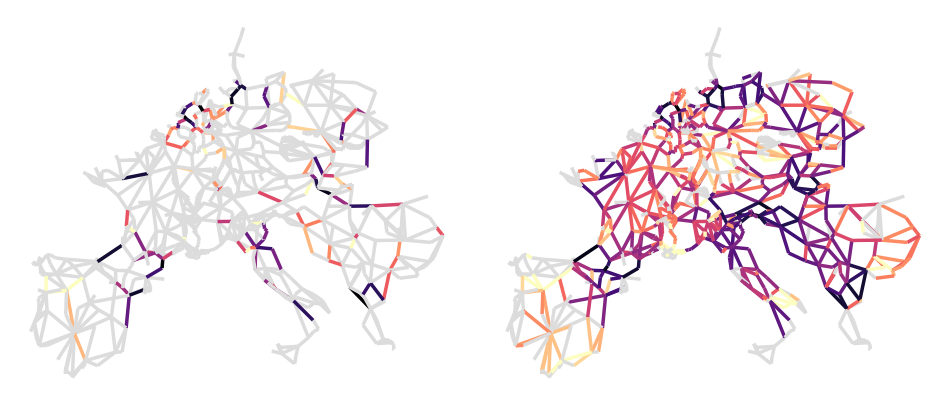

In [210]:
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

f,ax = plt.subplots(1,2,figsize = (12,5))
f.subplots_adjust(hspace = 0.05,wspace = 0.05)


cmap = copy.copy(mpl.cm.get_cmap("magma_r"))
cmap.set_under('gainsboro',1.0)
    
pos = nx.get_node_attributes(G,'pos')

likelihood = [likelihood_primary[(u,v)] for u,v in G.edges()]

c_H = np.array([np.log10(x) if x>1e-8 else -np.inf for x in likelihood])#PTDF[:,link])])
vmax = 10**(np.max(c_H[np.logical_and(np.logical_and(~np.isnan(c_H),c_H!=-float("inf")),c_H!=1e5)]))
vmin = 10**(np.min(c_H[np.logical_and(~np.isnan(c_H),c_H!=-float("inf"))]))
#vmin = np.min([9e-5,vmin])
#vmax = np.max([1.0,vmax])
print(vmax)
print(vmin)
nodes = nx.draw_networkx_nodes(G, 
                               pos = pos,
                               ax = ax[0],
                               node_color = 'black',
                               node_size = 0)

edges = nx.draw_networkx_edges(G, 
                               pos = pos,
                               ax = ax[0], 
                               edge_color = c_H,
                               width = 2.5,
                               edge_cmap = cmap,
                               edge_vmin = np.log10(vmin),
                               edge_vmax = np.log10(vmax))

ax[0].axis('off')
#ax[0].set_title(years[i],fontsize = 40)
    
#cbar_ax = f.add_axes([0.91, 0.575, 0.007, 0.3])#    
#sm = plt.cm.ScalarMappable(cmap = cmap,norm = mplcolors.LogNorm(vmin = vmin,vmax = vmax)) 
#cb = f.colorbar(sm,cax = cbar_ax)
#cb.ax.tick_params(labelsize = 30, width = 1.0, which = 'both')
#    
#    
#cmap = copy.copy(mpl.cm.get_cmap("viridis_r"))
#cmap.set_under('gainsboro',1.0)
#
    

likelihood = np.array([likelihood_secondary[(u,v)] for u,v in G.edges()])

c_H = np.array([np.log10(x) if x>1e-8 else -np.inf for x in likelihood])#PTDF[:,link])])
vmax = 10**(np.max(c_H[np.logical_and(np.logical_and(~np.isnan(c_H),c_H!=-float("inf")),c_H!=1e5)]))
vmin = 10**(np.min(c_H[np.logical_and(~np.isnan(c_H),c_H!=-float("inf"))]))
print(vmin,vmax)
#vmin = np.min([1e-7,vmin])
#vmax = np.max([3e-3,vmax])
print(vmin)
print(vmax)
nodes = nx.draw_networkx_nodes(G, 
                               pos = pos,
                               ax = ax[1],
                               node_color = 'black',
                               node_size = 0)

edges = nx.draw_networkx_edges(G, 
                               pos = pos,
                               ax = ax[1], 
                               edge_color = c_H,
                               width = 2.5,
                               edge_cmap = cmap,
                               edge_vmin = np.log10(vmin),
                               edge_vmax = np.log10(vmax))

ax[1].axis('off')
        #(datetime.datetime.strptime(str(i+1), "%m").strftime("%b"), fontsize = 24)


#plt.suptitle('Most likely splits - 2014', fontsize = 30)
#plt.savefig('/home/franz/ownCloud/system-split/Results/Figures/Likely_splits_edge_based_Germany_all years.pdf',bbox_inches = 'tight')

plt.show()

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.0-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this wil

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.5-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this wil

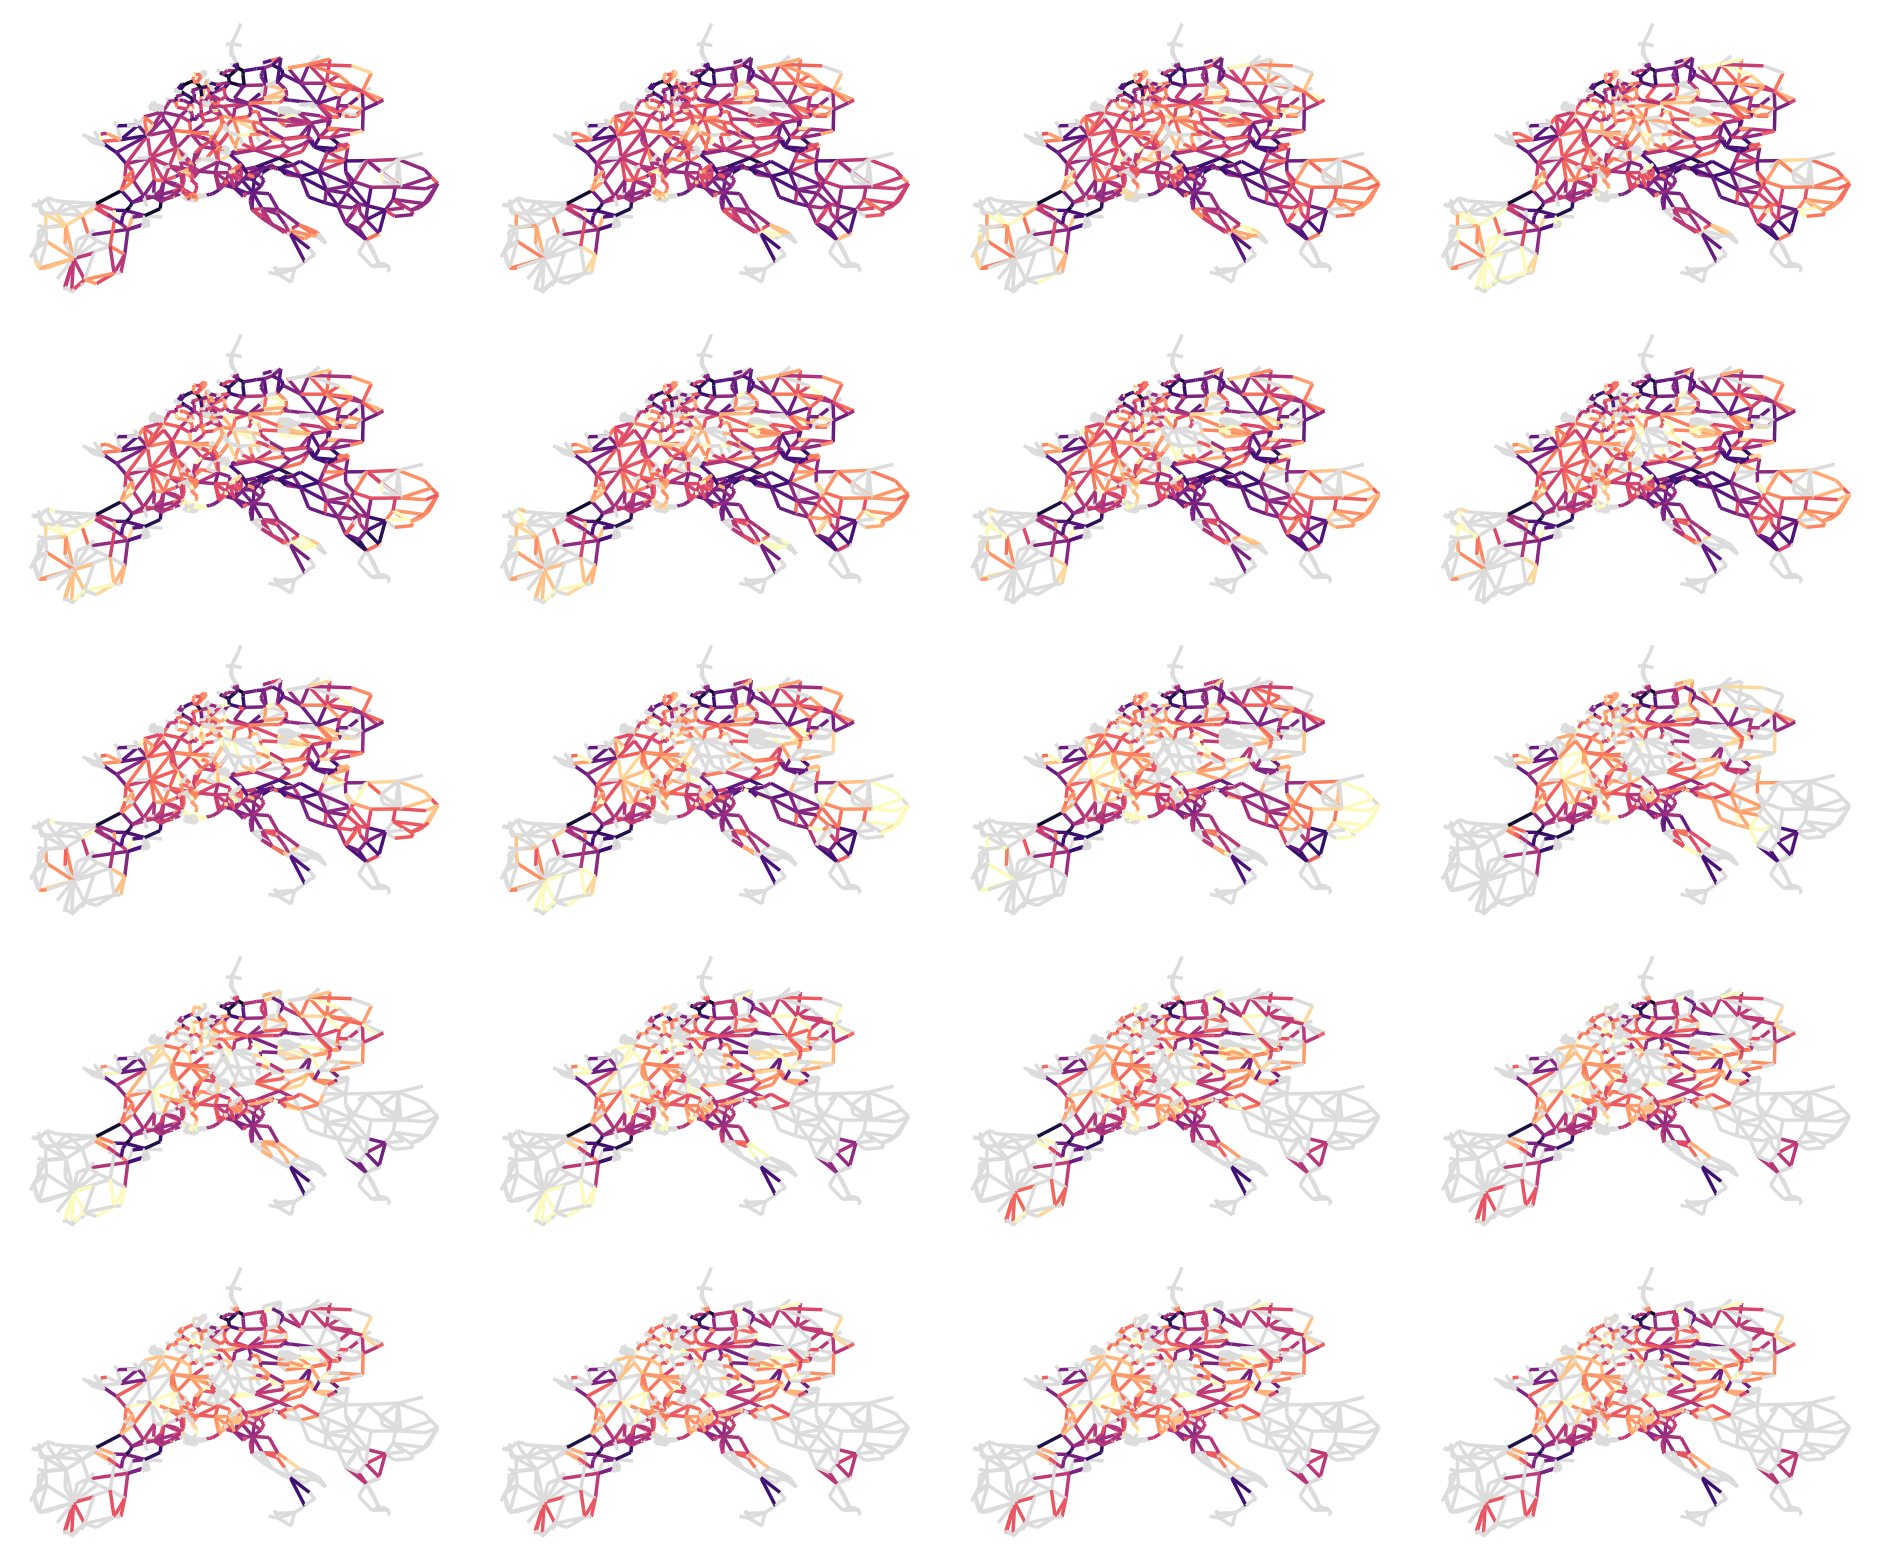

In [477]:
f,ax = plt.subplots(5,4,figsize = (24,20))

mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

cmap = copy.copy(mpl.cm.get_cmap("magma_r"))
cmap.set_under('gainsboro',1.0)
    
f.subplots_adjust(hspace = 0.05,wspace = 0.05)

vmaxvals = []
vminvals = []
for count,co2l in enumerate(co2ls):
    xcoord = int(count//4)
    ycoord = int(count%4)

    path_to_pypsa_network   = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/'
    results_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/Results/'
    
    network = pypsa.Network()
    currentlevel = np.round(co2l,2)
    network.import_from_netcdf(path_to_pypsa_network+f'elec_s_800_ec_lv1.0_Co2L{currentlevel}-3H.nc') # +year+'/elec_s_306_ec_lv1.0_1H.nc')#
    
    criterion = 'nodes'
    snet_index = 0
    
    
    G = utils.build_networkx_graph(network,snet_index = snet_index)
    
    splitting_cascades = pickle.load(open(results_path+
                                          f'system_splits_Co2L{currentlevel}.pickle' ,'rb'))
    
    solution_dict = pickle.load(open(results_path+f'Europe_Co2L{currentlevel}_split_evaluation_'+criterion+'_based_snet_%i'%snet_index+'.pickle','rb'))
    
    number_of_snapshots = len(network.snapshots)
    
    likelihood_primary, likelihood_secondary = visualisation.calc_likelihood_failure(G,
                                                                splitting_cascades,
                                                                number_of_snapshots,
                                                                solution_dict = solution_dict)
    likelihood = [likelihood_secondary[(u,v)] for u,v in G.edges()]
    
    c_H = np.array([np.log10(x) if x>1e-8 else -np.inf for x in likelihood])#PTDF[:,link])])

    vmax = 3.2e-3#10**(np.max(c_H[np.logical_and(np.logical_and(~np.isnan(c_H),c_H!=-float("inf")),c_H!=1e5)]))
    vmin = 3.2e-7#10**(np.min(c_H[np.logical_and(~np.isnan(c_H),c_H!=-float("inf"))]))  
    #print(vmax,vmin)
    vmaxvals.append(vmax)
    vminvals.append(vmin)
    nodes = nx.draw_networkx_nodes(G, 
                                   pos = pos,
                                   ax = ax[xcoord,ycoord],
                                   node_color = 'black',
                                   node_size = 0)
    
    edges = nx.draw_networkx_edges(G, 
                                   pos = pos,
                                   ax = ax[xcoord,ycoord], 
                                   edge_color = c_H,
                                   width = 2.5,
                                   edge_cmap = cmap,
                                   edge_vmin = np.log10(vmin),
                                   edge_vmax = np.log10(vmax))
    
    ax[xcoord,ycoord].axis('off')    
    
    
    #ax[xcoord,ycoord].scatter([0],[1])

plt.savefig(save_path+'Secondary_likelihoods_Europe.pdf',bbox_inches = 'tight')

plt.show()

In [476]:
print(np.max(vmaxvals),np.min(vminvals))

0.0031243205044570684 3.3974777125462067e-07


<ipython-input-218-07812e73b9fd>:22: RuntimeWarning: divide by zero encountered in double_scalars
  RoCoF.append(solution_dict[key][j]['load_imbalance'][k]/solution_dict[key][j]['inertia_proxy'][k])


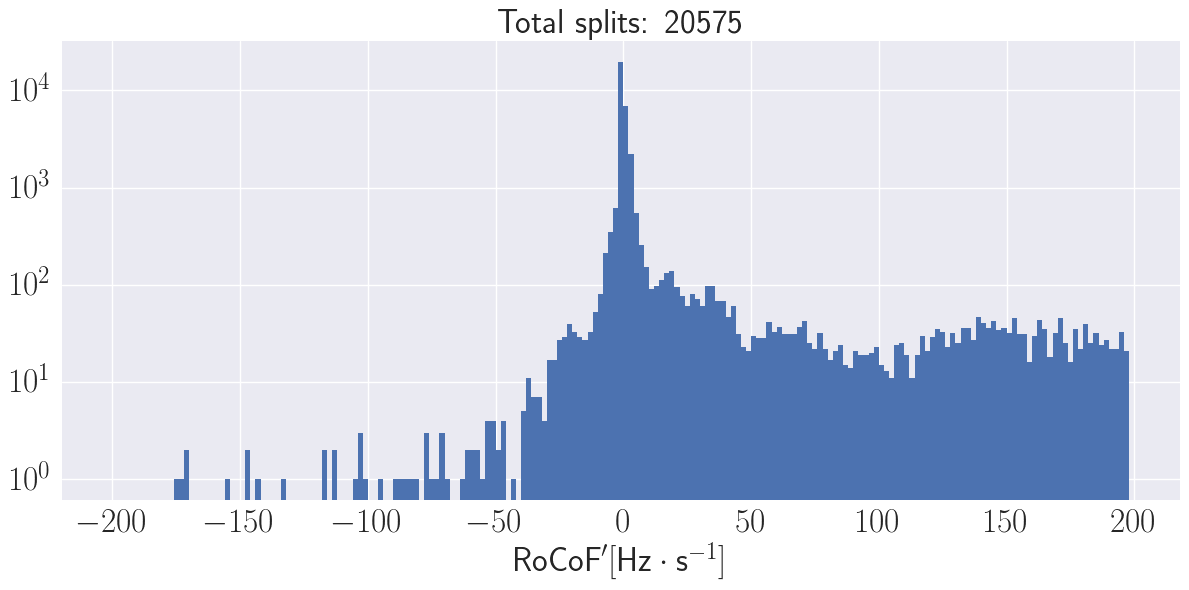

In [218]:
mpl.style.use('seaborn')
plt.rc('text', usetex = True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')


f,ax = plt.subplots(1,figsize = (12,6))#plt.subplots(5,2,figsize = (24,50))


splitting_cascades =  pickle.load(open(results_path+
                                      'system_splits_Co2L%.1f.pickle' % ( co2l),'rb'))

solution_dict = pickle.load(open(results_path+'Europe_Co2L%.1f_split_evaluation_'%co2l+criterion+'_based_snet_%i'%snet_index+'.pickle','rb'))


nof_splits = 0
RoCoF = []
load_imbalances = []
inertia_proxies = []
for key in solution_dict.keys():
    for j in range(len(solution_dict[key]))[1::2]:
        for k in range(len(solution_dict[key][j]['load_imbalance'])):
            RoCoF.append(solution_dict[key][j]['load_imbalance'][k]/solution_dict[key][j]['inertia_proxy'][k])
            load_imbalances.append(solution_dict[key][j]['load_imbalance'][k])
            inertia_proxies.append(solution_dict[key][j]['inertia_proxy'][k])
        #print(key, j)
        #print(np.array(comp_sizes))
        
        #print(50/12*np.array(solution_dict[key][j]['load_imbalance'])/np.array(solution_dict[key][j]['inertia_proxy']))

        nof_splits += 1    
RoCoF = (np.array(RoCoF)*50/2/6).flatten()
maxval = 200
bins = np.arange(-maxval,maxval,2)
ax.hist(RoCoF.flatten(),bins = bins)#i//2,i%2
ax.tick_params(axis = 'both', which = 'both', labelsize = 24)
ax.set_yscale('log')
ax.set_xlabel(r'$\text{RoCoF}^\prime  [\text{Hz} \cdot \text{s}^{-1}]$',fontsize = 24)
ax.set_title('Total splits: %i'%nof_splits, fontsize = 24)
#bins = np.arange(-1e5,1e5,500)
#ax[i,0].hist(load_imbalances,bins = bins)#i//2,i%2
#ax[i,0].tick_params(axis = 'both', which = 'both', labelsize = 24)
#ax[i,0].set_yscale('log')
#ax[i,0].set_xlim([-2e4,2e4])
#ax[i,0].set_xlabel(r'$\Delta P$',fontsize = 24)
#ax[i,0].scatter([],[],s = 0,label = '%i'%year,color = 'C0')
#ax[i,0].legend(fontsize = 24)
#ax[i,0].set_title('Total splits: %i'%nof_splits, fontsize = 24)
#
#bins = np.arange(0,1e6,500)
#
#ax[i,1].hist(inertia_proxies,bins = bins)#i//2,i%2
#ax[i,1].tick_params(axis = 'both', which = 'both', labelsize = 24)
#ax[i,1].set_yscale('log')
#ax[i,1].set_xlim([0,1e5])
#ax[i,1].set_xlabel(r'inertia proxies',fontsize = 24)
#ax[i,1].scatter([],[],s = 0,label = '%i'%year,color = 'C0')
#ax[i,1].legend(fontsize = 24)
#ax[i,1].set_title('Total splits: %i'%nof_splits, fontsize = 24)
plt.tight_layout()
#plt.savefig(save_path+'inertias_and_load_imbalances_Germany.pdf')
#the_split = splitting_cascades['01_09_2013_12'] 1 12

In [ ]:
print()

[91304.84099772  1775.78834545     0.             0.
     0.             0.             0.        ]
[-15114.31847142   4539.42964434   2185.59211857   2469.03882109
   5576.30387937     61.27865874    282.70200623]
[-0.689737   10.65120752         inf         inf         inf         inf
         inf]


<ipython-input-155-6140566028fe>:8: RuntimeWarning: divide by zero encountered in true_divide
  print(50/12*np.array(solution_dict[timestamp][index]['load_imbalance'])/np.array(solution_dict[timestamp][index]['inertia_proxy']))


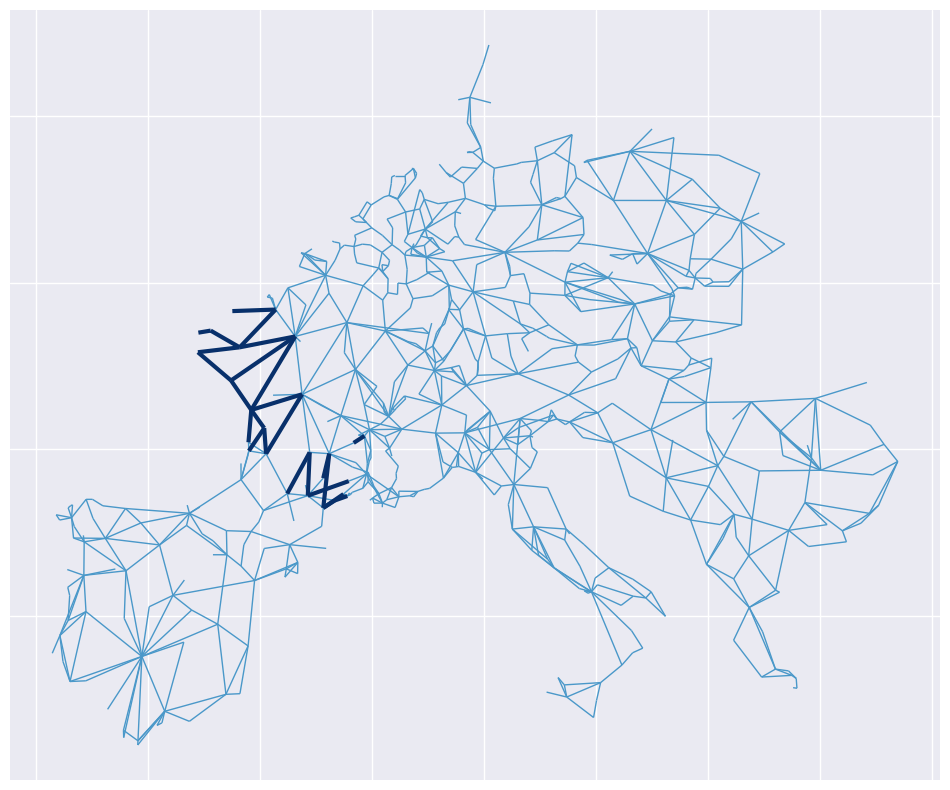

In [155]:
timestamp = '05_02_2013_12'
index = 1
the_cascade = splitting_cascades[timestamp][solution_dict[timestamp][index-1]]

split_comps = utils.get_split_components(the_cascade,G,criterion = 'load')
print(np.array(solution_dict[timestamp][index]['inertia_proxy']))
print(np.array(solution_dict[timestamp][index]['load_imbalance']))
print(50/12*np.array(solution_dict[timestamp][index]['load_imbalance'])/np.array(solution_dict[timestamp][index]['inertia_proxy']))

f,ax = plt.subplots(figsize=(12,10))
cmap = plt.get_cmap('Blues')
nodes = nx.draw_networkx_nodes(G, 
                               pos = pos,
                               ax = ax,
                               node_color = 'black',
                               node_size = 0)

edges = nx.draw_networkx_edges(split_comps[0], 
                               pos = pos,
                               ax = ax, 
                               edge_color = cmap(0.6),
                               width = 1,)
edges = nx.draw_networkx_edges(split_comps[1], 
                               pos = pos,
                               ax = ax, 
                               edge_color = cmap(0.6),
                               width = 1,)
edge_graph = nx.Graph()
edge_graph.add_edges_from(the_cascade)
edges = nx.draw_networkx_edges(edge_graph, 
                               pos = pos,
                               ax = ax, 
                               edge_color = cmap(1.0),
                               width = 3,)

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.0-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


0.00034246575342465743 0.6554794520548134
3.3974777125462067e-07 0.0031243205044570684


/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.1-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


0.00034246575342465743 0.5465753424657683
3.3974777125462067e-07 0.001955927919113026


/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.2-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


...

0.00034246575342465743 0.4102739726027496
3.3974777125462067e-07 0.0013854914111764468


/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.4-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


0.00034246575342465743 0.48116438356165636
3.3974777125462067e-07 0.0014537807131986345


/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.5-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


0.00034246575342465743 0.5407534246575489
3.3974777125462067e-07 0.0014894542291803735


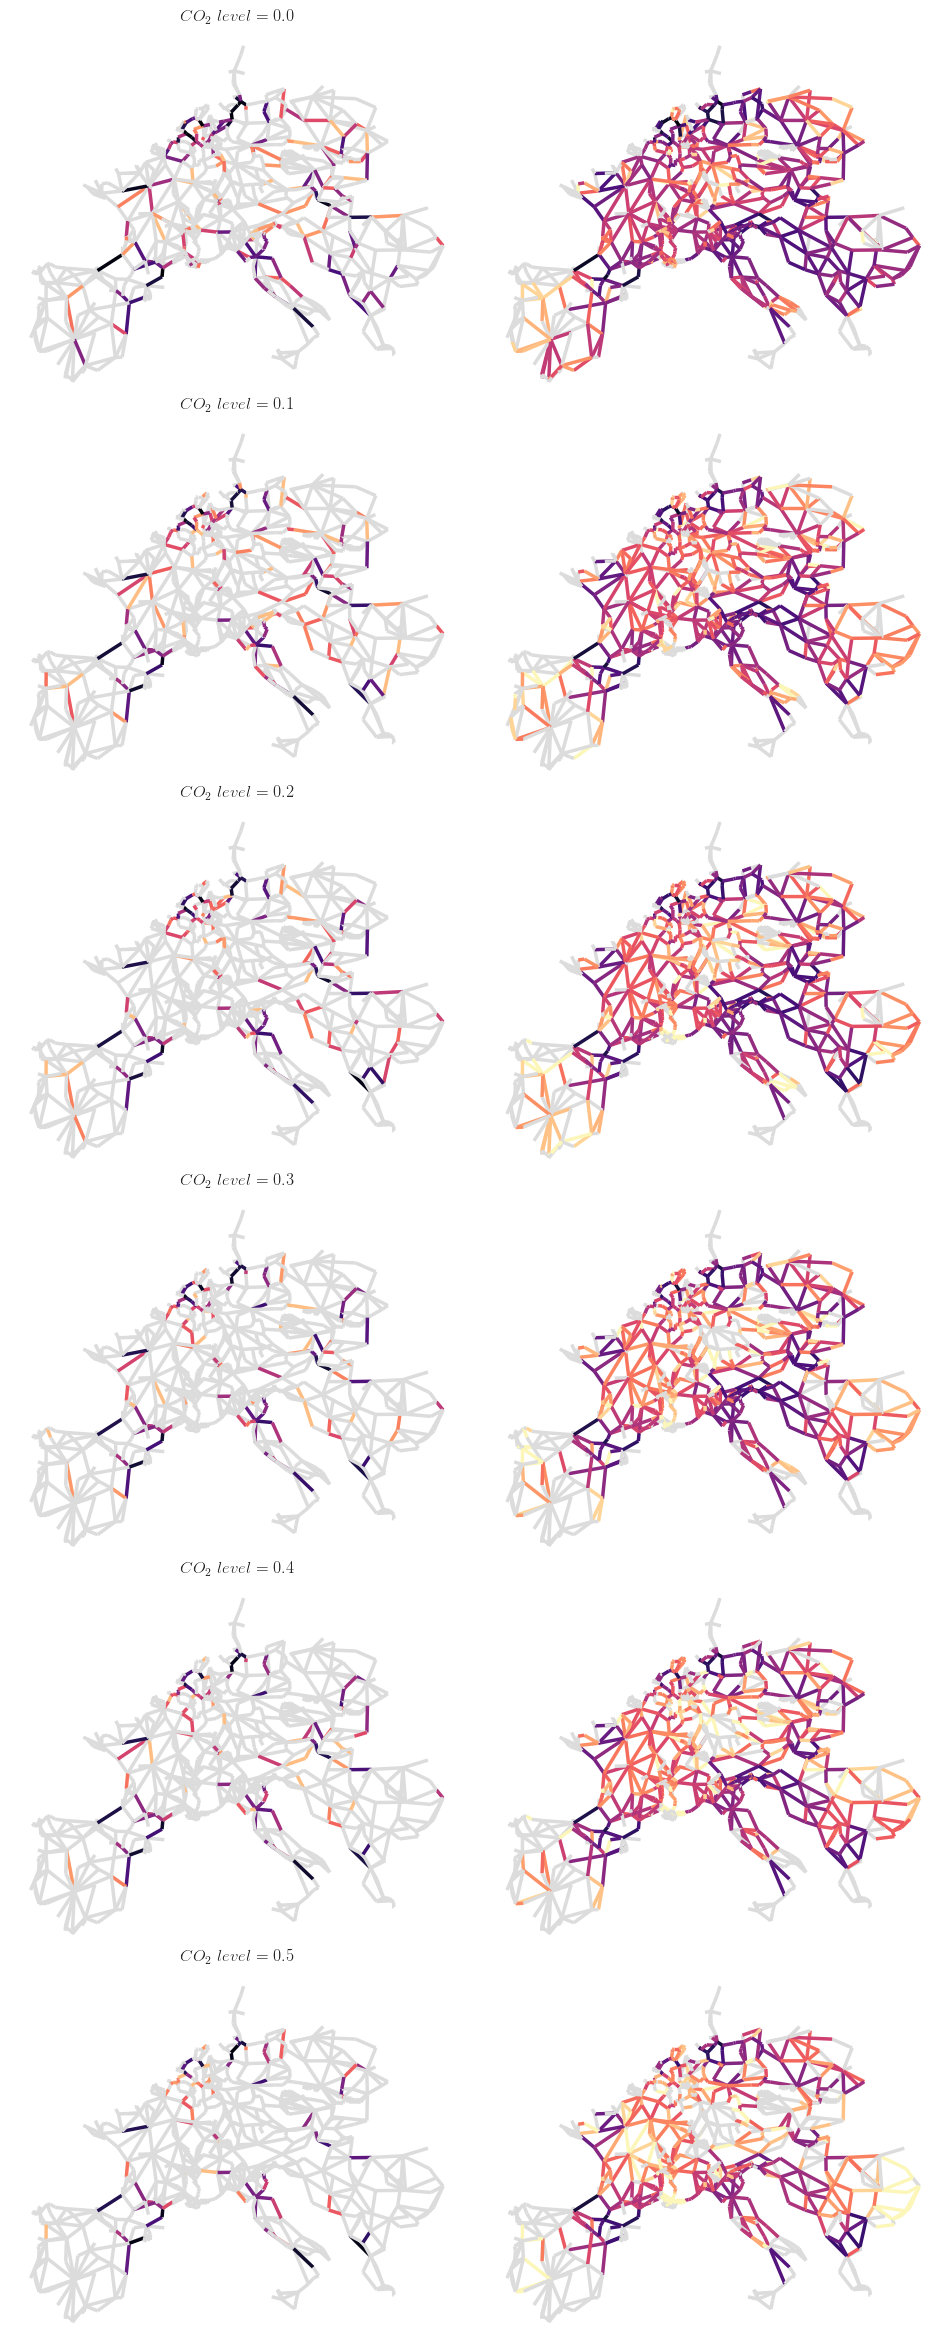

In [220]:
f,ax = plt.subplots(6,2,figsize = (12,30))
f.subplots_adjust(hspace = 0.05,wspace = 0.05)
cmap = copy.copy(mpl.cm.get_cmap("magma_r"))
cmap.set_under('gainsboro',1.0)

snet_index = 0
criterion = 'nodes'
co2ls = np.arange(0.0,0.55,0.05)

for count,co2l in enumerate(co2ls):
    path_to_pypsa_network   = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/'
    results_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/Results/'
    
    network = pypsa.Network()
    network.import_from_netcdf(path_to_pypsa_network+f'elec_s_800_ec_lv1.0_Co2L{co2l}-3H.nc')    

    
    G = utils.build_networkx_graph(network, snet_index = snet_index)
    
    
    splitting_cascades = pickle.load(open(results_path+
                                          f'system_splits_Co2L{co2l}.pickle','rb'))
    
    solution_dict = pickle.load(open(results_path+f'Europe_Co2L{co2l}_split_evaluation_'+criterion+f'_based_snet_{snet_index}.pickle','rb'))
    
    number_of_snapshots = len(network.snapshots)
    
    likelihood_primary, likelihood_secondary = visualisation.calc_likelihood_failure(G,
                                                                splitting_cascades,
                                                                number_of_snapshots,
                                                                solution_dict = solution_dict)
    
        
    likelihood = [likelihood_primary[(u,v)] for u,v in G.edges()]
    
    c_H = np.array([np.log10(x) if x>1e-8 else -np.inf for x in likelihood])#PTDF[:,link])])
    vmax = 10**(np.max(c_H[np.logical_and(np.logical_and(~np.isnan(c_H),c_H!=-float("inf")),c_H!=1e5)]))
    vmin = 10**(np.min(c_H[np.logical_and(~np.isnan(c_H),c_H!=-float("inf"))]))
    
    print(vmin,vmax)
    
    vmax = 7e-1
    vmin = 1e-4

    nodes = nx.draw_networkx_nodes(G, 
                                   pos = pos,
                                   ax = ax[count,0],
                                   node_color = 'black',
                                   node_size = 0)
    
    edges = nx.draw_networkx_edges(G, 
                                   pos = pos,
                                   ax = ax[count,0], 
                                   edge_color = c_H,
                                   width = 2.5,
                                   edge_cmap = cmap,
                                   edge_vmin = np.log10(vmin),
                                   edge_vmax = np.log10(vmax))
    
    ax[count,0].axis('off')
    ax[count,0].set_title(r'$CO_2~level = %.1f$'%co2l)
    
    likelihood = np.array([likelihood_secondary[(u,v)] for u,v in G.edges()])
    
    c_H = np.array([np.log10(x) if x>1e-8 else -np.inf for x in likelihood])#PTDF[:,link])])
    vmax = 10**(np.max(c_H[np.logical_and(np.logical_and(~np.isnan(c_H),c_H!=-float("inf")),c_H!=1e5)]))
    vmin = 10**(np.min(c_H[np.logical_and(~np.isnan(c_H),c_H!=-float("inf"))]))
    print(vmin,vmax)

    vmin = 3e-7
    vmax = 4e-3
    nodes = nx.draw_networkx_nodes(G, 
                                   pos = pos,
                                   ax = ax[count,1],
                                   node_color = 'black',
                                   node_size = 0)
    
    edges = nx.draw_networkx_edges(G, 
                                   pos = pos,
                                   ax = ax[count,1], 
                                   edge_color = c_H,
                                   width = 2.5,
                                   edge_cmap = cmap,
                                   edge_vmin = np.log10(vmin),
                                   edge_vmax = np.log10(vmax))
    
    ax[count,1].axis('off')

plt.savefig(path + 'Data/system_split/European_Networks/New_networks_CO2_levels/'+'Failure_likelihoods_Europe_'+criterion+'_based.pdf',bbox_inches = 'tight')
plt.show()

In [366]:
co2l = 0.1
print(rf'$CO_2~level = {co2l}$' + ' Hello')

$CO_2~level = 0.1$ Hello


/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.5-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
<ipython-input-349-1d763422d048>:41: RuntimeWarning: divide by zero encountered in double_scalars
  RoCoF[count].append(solution_dict[key][j]['load_imbalance'][k]/solution_dict[k

02_11_2013_12 6
-111.47915763211944
02_11_2013_12 7
-132.43194785575616
02_11_2013_12 10
-132.43194785575616


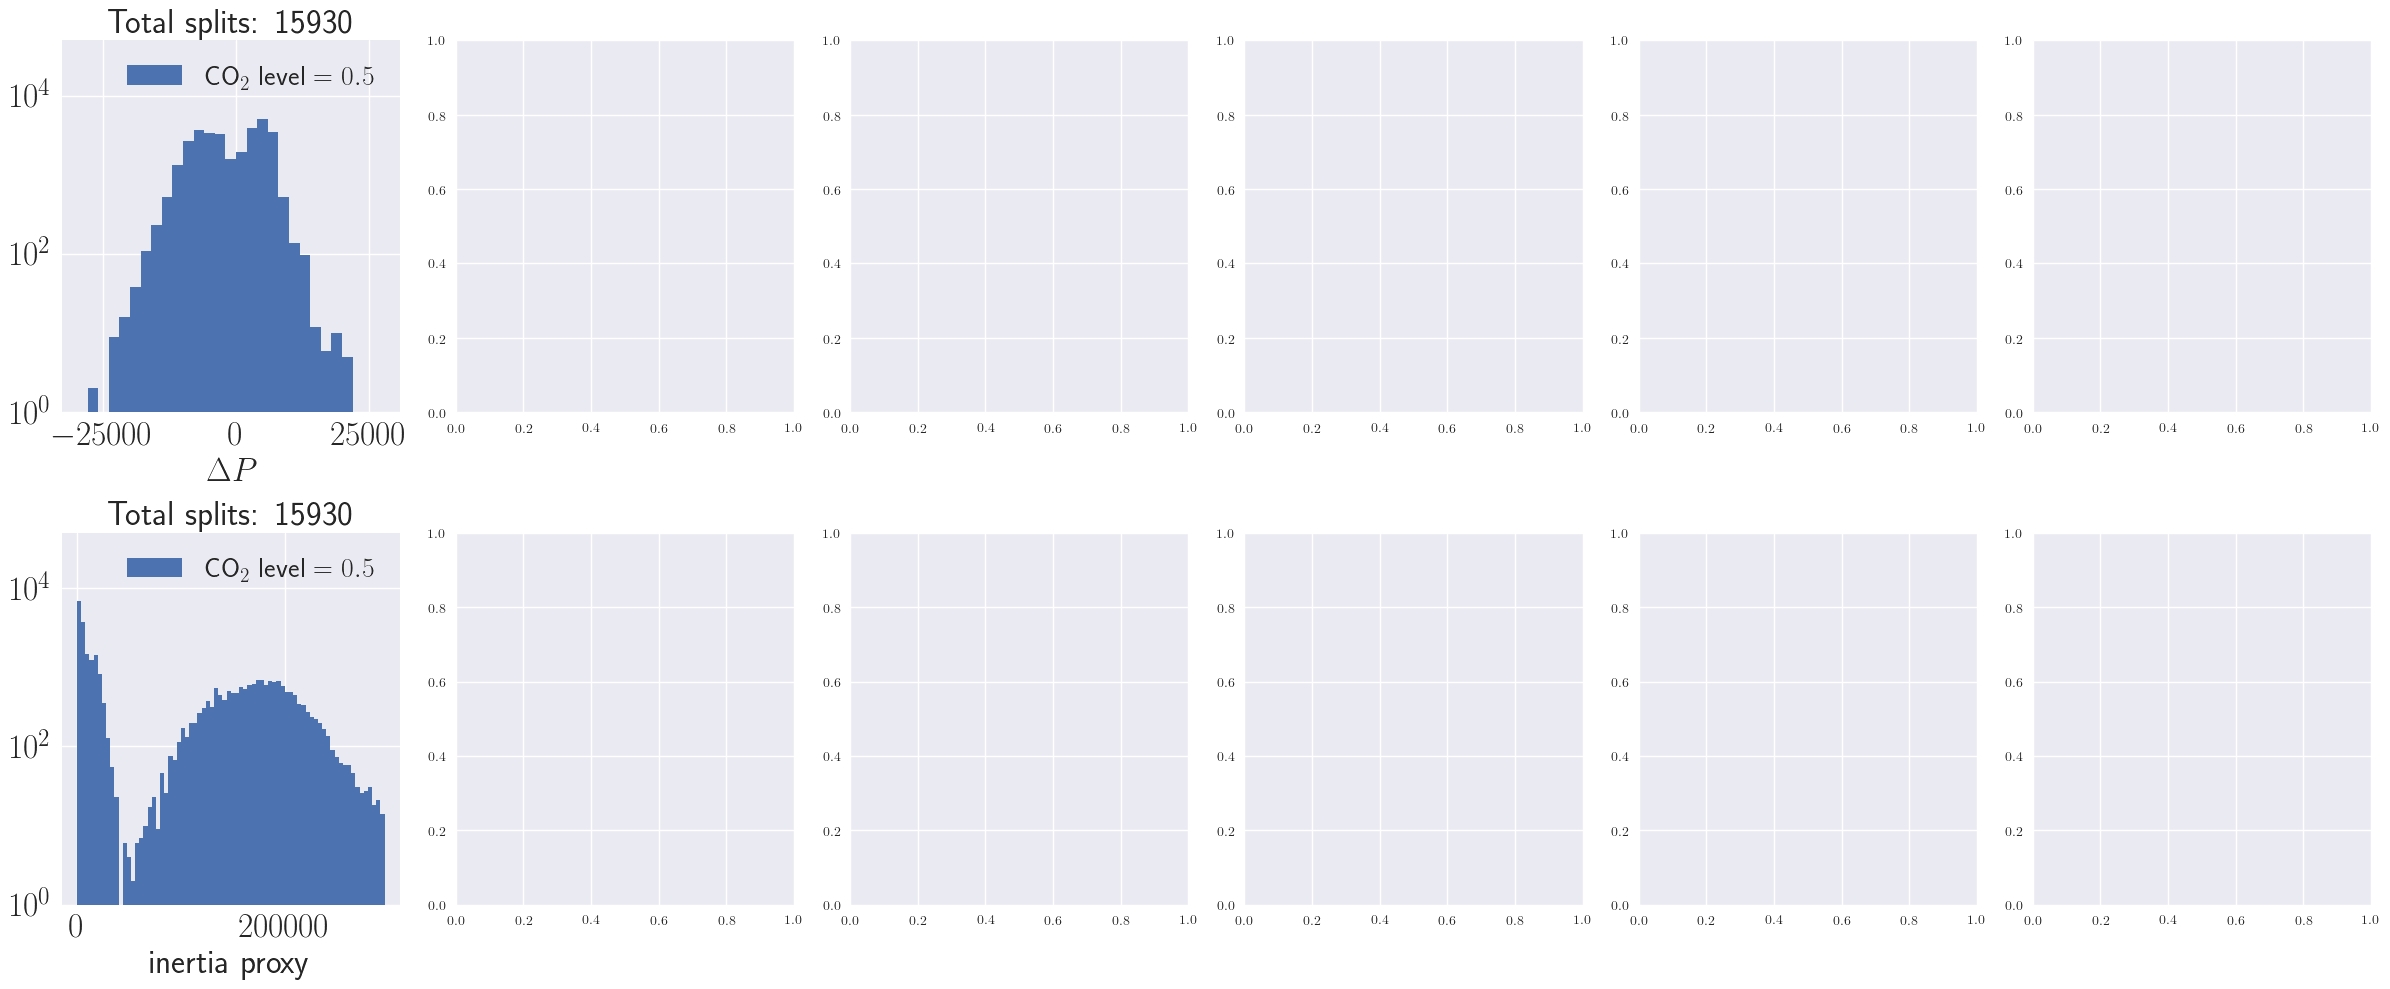

In [349]:
mpl.style.use('seaborn')
plt.rc('text', usetex = True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

path = '/media/fkaiser/'
save_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/'

path_to_pypsa_network   = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/'
results_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/Results/'

f,ax = plt.subplots(2,6,figsize = (24,10))#plt.subplots(5,2,figsize = (24,50))

RoCoF = []
load_imbalances = []
inertia_proxies = []
co2ls = [0.5]

for count,co2l in enumerate(co2ls):
    RoCoF.append([])
    load_imbalances.append([])
    inertia_proxies.append([])
    
    network = pypsa.Network()
    network.import_from_netcdf(path_to_pypsa_network+'elec_s_800_ec_lv1.0_Co2L%.1f-3H.nc'%co2l)

    
    G = utils.build_networkx_graph(network, snet_index = snet_index)
    
    
    splitting_cascades = pickle.load(open(results_path+
                                          'system_splits_Co2L%.1f.pickle' % ( co2l),'rb'))
    
    solution_dict = pickle.load(open(results_path+'Europe_Co2L%.1f_split_evaluation_'%co2l+criterion+'_based_snet_%i'%snet_index+'.pickle','rb'))
    
    nof_splits = 0

    for key in solution_dict.keys():
        for j in range(len(solution_dict[key]))[1::2]:
            current_rocofs = []
            for k in range(len(solution_dict[key][j]['load_imbalance'])):
                RoCoF[count].append(solution_dict[key][j]['load_imbalance'][k]/solution_dict[key][j]['inertia_proxy'][k])
                load_imbalances[count].append(solution_dict[key][j]['load_imbalance'][k])
                inertia_proxies[count].append(solution_dict[key][j]['inertia_proxy'][k])
                current_rocofs.append(RoCoF[count][-1])
            minval = np.min(current_rocofs)
            if  -100000<minval<-70*12/50:
                print(key,solution_dict[key][j-1])
                print(minval*50/12)
            nof_splits += 1    
    #RoCoF = (np.array(RoCoF)*50/2/6).flatten()
    maxval = int(3e4)
    bins = np.arange(-maxval,maxval,2000)
    #ax[count].hist(RoCoF.flatten(),bins = bins, label = r'$\text{CO}_2\text{ level} = %.1f$'%co2l)#i//2,i%2
    ax[0,count].hist(load_imbalances[count],
                        bins = bins, 
                        label = r'$\text{CO}_2\text{ level} = %.1f$'%co2l)
    ax[0,count].set_xlabel(r'$\Delta P$',
                            fontsize = 24)

    maxval = int(3e5)
    bins = np.arange(0,maxval,4000)

    ax[1,count].hist(inertia_proxies[count],
                        bins = bins, 
                        label = r'$\text{CO}_2\text{ level} = %.1f$'%co2l)   
    ax[1,count].set_xlabel(r'inertia proxy',
                            fontsize = 24)
    for i in range(2):
        ax[i,count].tick_params(axis = 'both', which = 'both', labelsize = 24)
        ax[i,count].set_yscale('log')
        ax[i,count].set_title('Total splits: %i'%nof_splits, fontsize = 24)
        ax[i,count].legend(fontsize=20)
        ax[i,count].set_ylim([1,5e4])

plt.tight_layout()
#plt.savefig(save_path+'Europe_load_imbalance_and_inertia_proxies.pdf')

[<networkx.classes.graph.Graph object at 0x7f5ba62871f0>, <networkx.classes.graph.Graph object at 0x7f5b932c5fd0>]


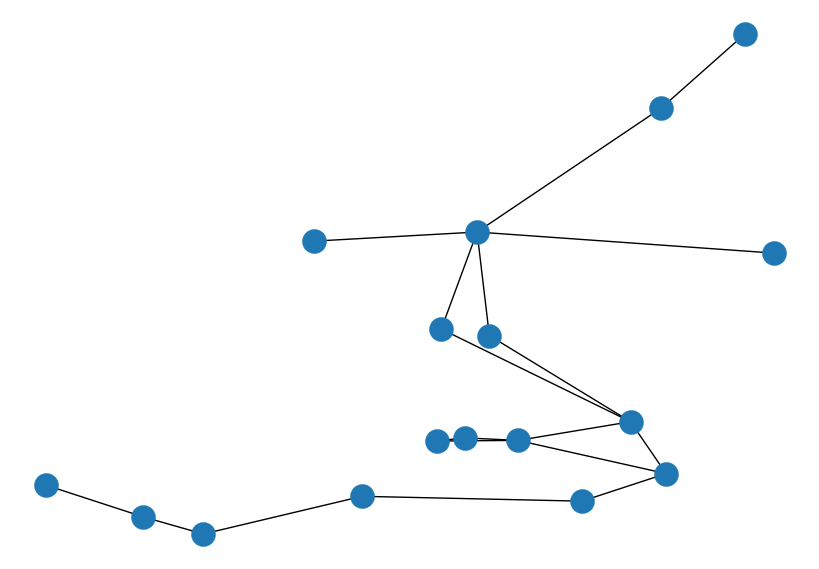

In [355]:
the_cascade = splitting_cascades['02_11_2013_12'][10]
comps = utils.get_split_components(the_cascade, G, criterion = criterion)
print(comps)
#nx.draw(comps[0],pos)
nx.draw(comps[1],pos)
plt.show()


In [451]:
mpl.style.use('seaborn')
plt.rc('text', usetex = True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

path = '/media/fkaiser/'
save_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/'

path_to_pypsa_network   = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/'
results_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/Results/'

#f,ax = plt.subplots(1,6,figsize = (24,5))#plt.subplots(5,2,figsize = (24,50))
RoCoF = []
load_imbalances = []
inertia_proxies = []

co2ls = np.arange(0.0,0.99,0.05)

for count,co2l in enumerate(co2ls):
    RoCoF.append([])
    load_imbalances.append([])
    inertia_proxies.append([])
    
    level = np.round(co2l,2)
    network = pypsa.Network()
    network.import_from_netcdf(path_to_pypsa_network+f'elec_s_800_ec_lv1.0_Co2L{level}-3H.nc')

    
    G = utils.build_networkx_graph(network, snet_index = snet_index)
    
    try: 
        splitting_cascades = pickle.load(open(results_path+
                                            f'system_splits_Co2L{level}.pickle','rb'))
    
        solution_dict = pickle.load(open(results_path+f'Europe_Co2L{level}_split_evaluation_'+criterion+'_based_snet_%i'%snet_index+'.pickle','rb'))
    except FileNotFoundError:
        print(f'Europe_Co2L{co2l:.2f}')
        continue
    
    nof_splits = 0

    for key in solution_dict.keys():
        for j in range(len(solution_dict[key]))[1::2]:
            for k in range(len(solution_dict[key][j]['load_imbalance'])):
                RoCoF[count].append(solution_dict[key][j]['load_imbalance'][k]/solution_dict[key][j]['inertia_proxy'][k])
                load_imbalances[count].append(solution_dict[key][j]['load_imbalance'][k])
                inertia_proxies[count].append(solution_dict[key][j]['inertia_proxy'][k])
                #if ((co2l == 0.5) & (-80<=solution_dict[key][j]['load_imbalance'][k]/solution_dict[key][j]['inertia_proxy'][k]<=-70)):
                #    print(key)
    
            nof_splits += 1    
    RoCoF[count] = (np.array(RoCoF[count])*50/2/6).flatten()
    #bins = np.arange(-150,300,5)
    #ax[count].hist(RoCoF.flatten(),bins = bins, label = r'$\text{CO}_2\text{ level} = %.1f$'%co2l)#i//2,i%2
    #ax[count].set_xlabel(r'$RoCoF$',
    #                       fontsize = 24)
#
    #ax[count].tick_params(axis = 'both', which = 'both', labelsize = 24)
    #ax[count].set_yscale('log')
    #ax[count].set_title('Total splits: %i'%nof_splits, fontsize = 24)
    #ax[count].legend(fontsize=20)
    #ax[count].set_ylim([1,5e4])

#plt.tight_layout()
#plt.savefig(save_path+'Europe_RoCoF_'+criterion+'_based.pdf')

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.0-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
<ipython-input-451-ee15058c04d1>:44: RuntimeWarning: divide by zero encountered in double_scalars
  RoCoF[count].append(solution_dict[key][j]['load_imbalance'][k]/solution_dict[k

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.4-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
<ipython-input-451-ee15058c04d1>:44: RuntimeWarning: divide by zero encountered in double_scalars
  RoCoF[count].append(solution_dict[key][j]['load_imbalance'][k]/solution_dict[k

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.8-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
<ipython-input-451-ee15058c04d1>:44: RuntimeWarning: divide by zero encountered in double_scalars
  RoCoF[count].append(solution_dict[key][j]['load_imbalance'][k]/solution_dict[k

In [373]:
np.round(0.15,2)

0.15

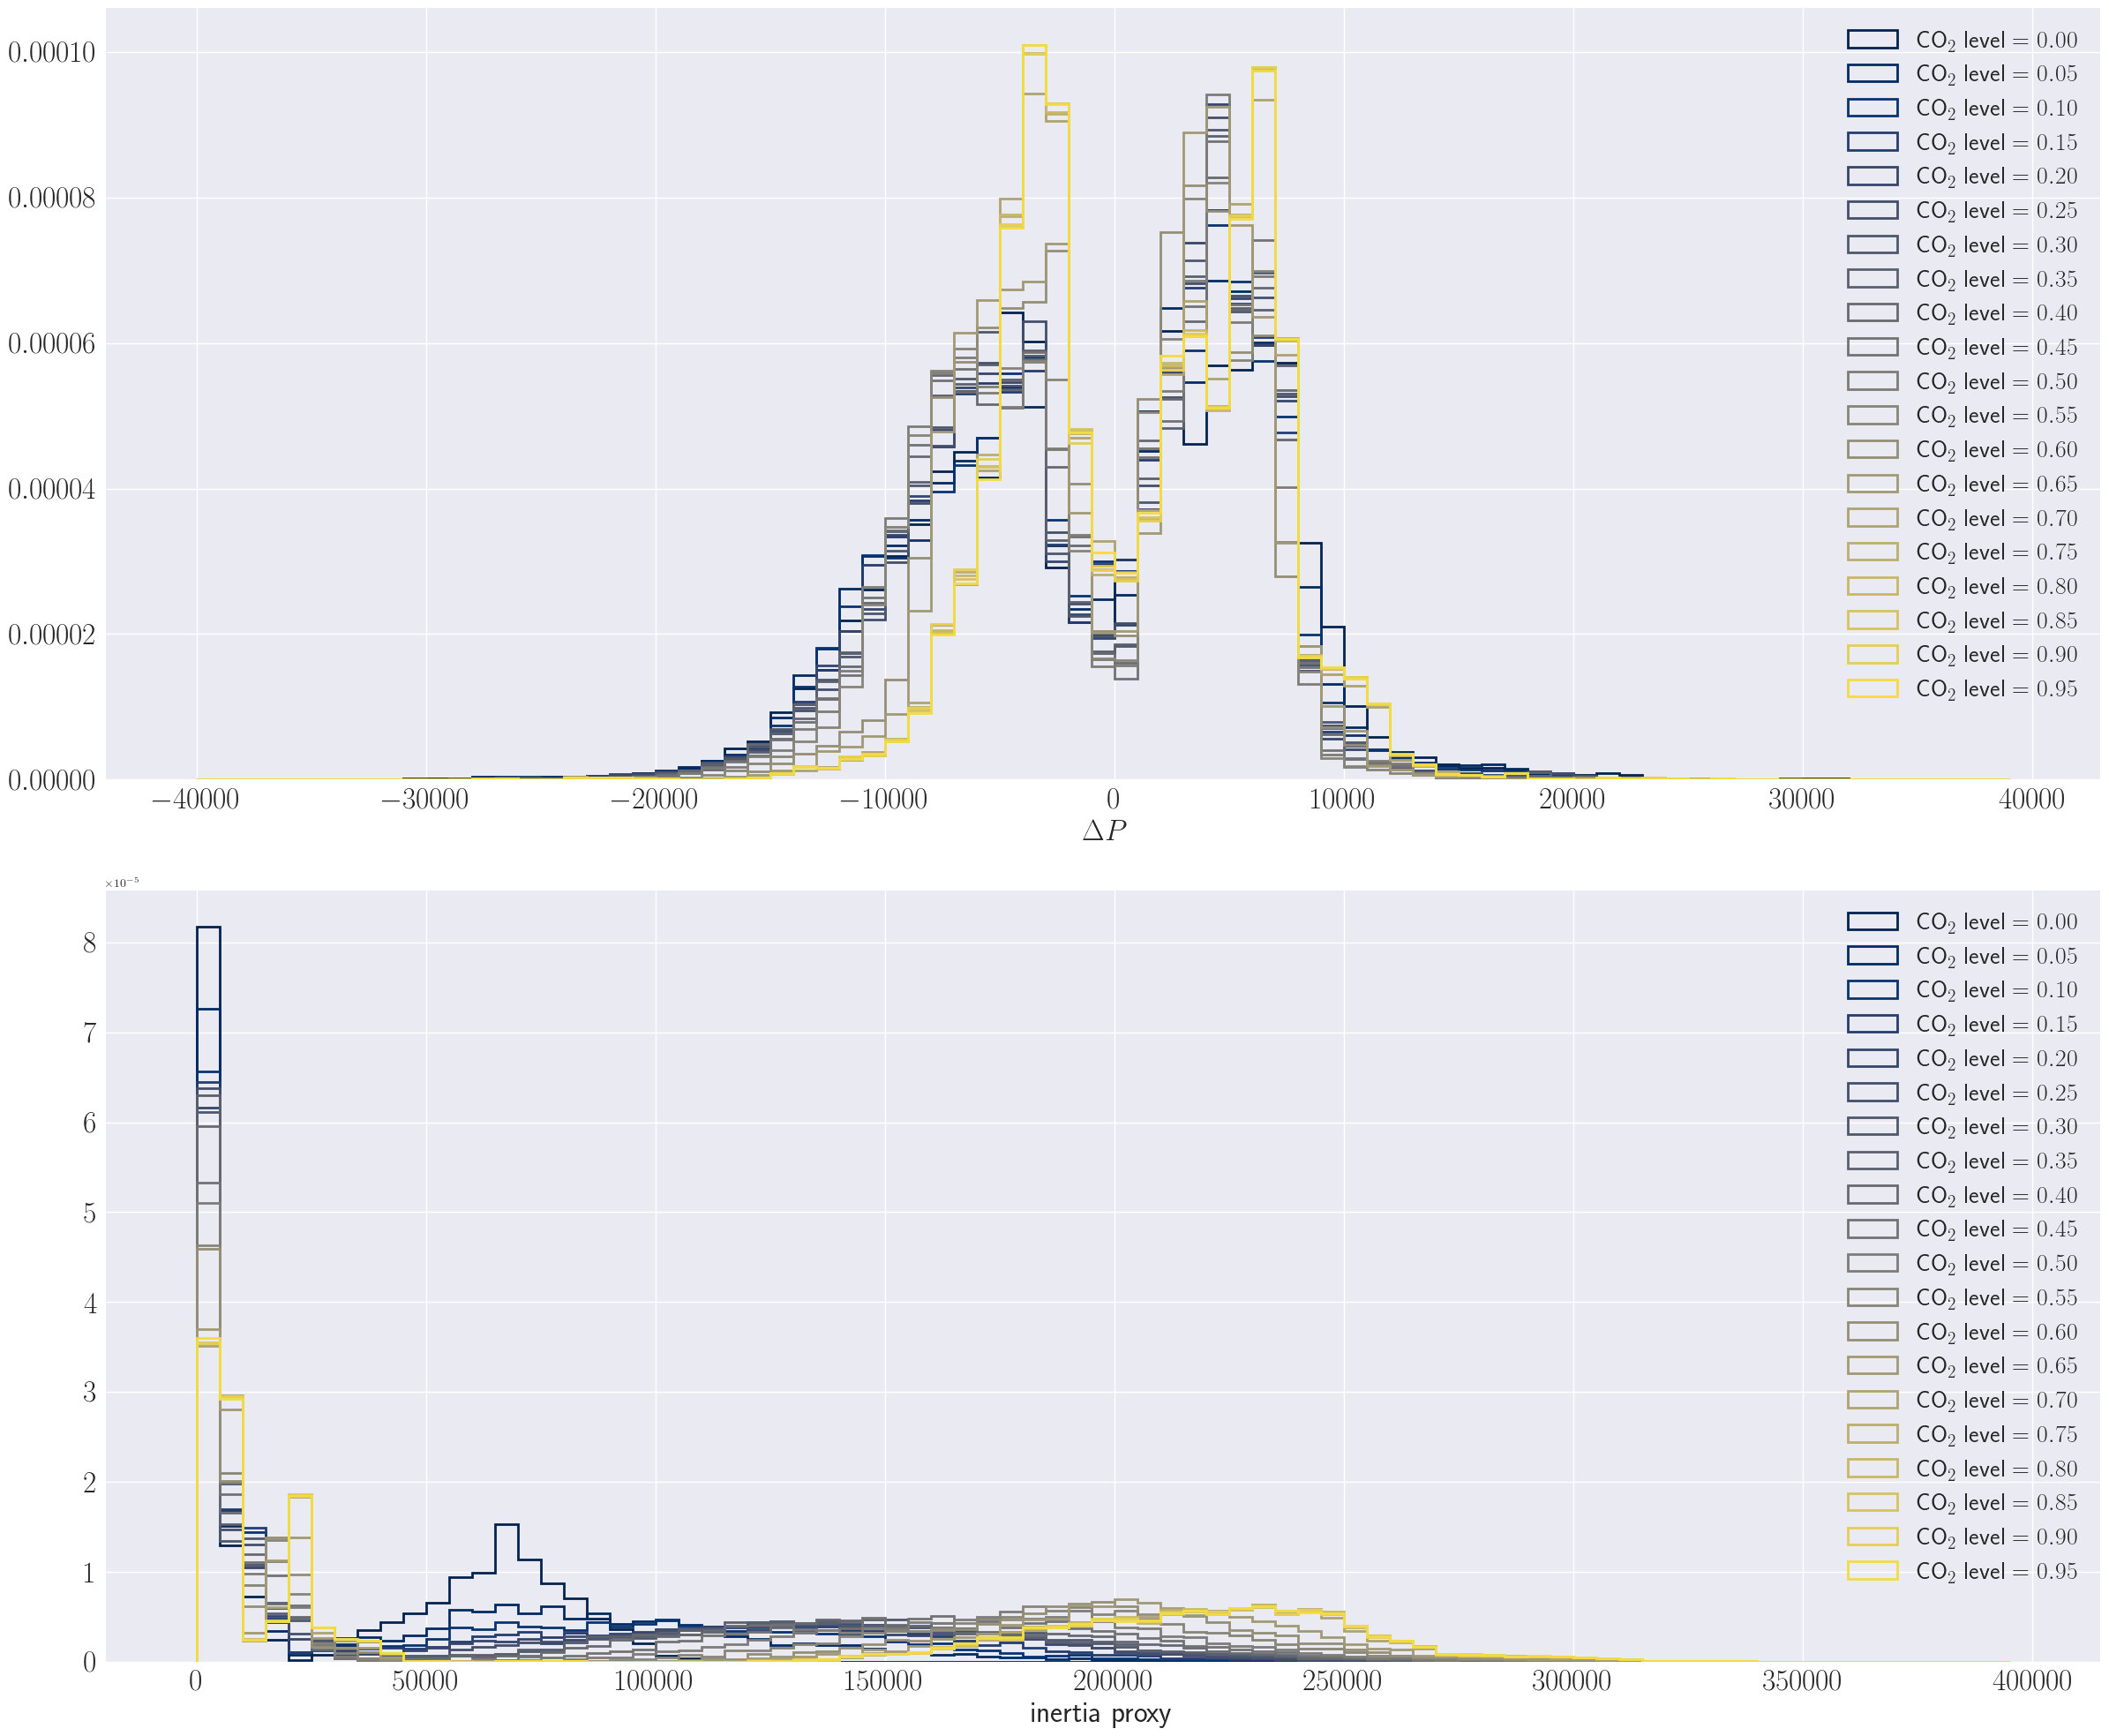

In [594]:
f,ax = plt.subplots(2,figsize = (24,20))#plt.subplots(5,2,figsize = (24,50))
cmap = plt.get_cmap('cividis')
for count,co2l in enumerate(co2ls):
    maxval = int(4e4)#3.5e4
    bins = np.arange(-maxval,maxval,1000)
    #ax[count].hist(RoCoF.flatten(),bins = bins, label = r'$\text{CO}_2\text{ level} = %.1f$'%co2l)#i//2,i%2
    if len(load_imbalances[count]):
        ax[0].hist(load_imbalances[count],
                            bins = bins, 
                            histtype='step',
                            label = r'$\text{CO}_2\text{ level} = %.2f$'%co2l,
                  linewidth = 2,
                  color = cmap(count/len(co2ls)),
                  density = True)
    
        
        maxval = int(4e5)#4e5
        bins = np.arange(0,maxval,5000)
        #bins = np.arange(0,5e3,500)
        ax[1].hist(inertia_proxies[count],
                            bins = bins, 
                            histtype='step',
                            label = r'$\text{CO}_2\text{ level} = %.2f$'%co2l,
                            linewidth = 2,
                  color = cmap(count/len(co2ls)),
                  density = True)   


ax[0].set_xlabel(r'$\Delta P$',
                            fontsize = 24)    
ax[1].set_xlabel(r'inertia proxy',
                            fontsize = 24)
for i in range(2):
        ax[i].tick_params(axis = 'both', which = 'both', labelsize = 24)
        #ax[i].set_yscale('log')
        ax[i].legend(fontsize=20)
        #ax[i].set_ylim([1,5e4])
plt.tight_layout()

#plt.savefig(save_path+'Europe_load_imbalance_and_inertia_proxies_step_histogram_linear_scale.pdf',bbox_inches = 'tight')
plt.show()

In [596]:
load_imbalances_negative_vals = np.zeros((len(co2ls),2))
for count,co2l in enumerate(co2ls):
    current_vals = np.array(load_imbalances[count])[np.array(load_imbalances[count])<0]
    load_imbalances_negative_vals[count,0] = np.mean(current_vals)
    load_imbalances_negative_vals[count,1] = np.median(current_vals)


In [600]:
202900106800/2e8

[autoreload of _frozen_importlib failed: Traceback (most recent call last):
  File "/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 245, in check
    superreload(m, reload, self.old_objects)
  File "/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 394, in superreload
    module = reload(module)
  File "/home/fkaiser/.conda/envs/system_split/lib/python3.9/imp.py", line 314, in reload
    return importlib.reload(module)
  File "/home/fkaiser/.conda/envs/system_split/lib/python3.9/importlib/__init__.py", line 166, in reload
    spec = module.__spec__ = _bootstrap._find_spec(name, pkgpath, target)
AttributeError: module 'importlib._bootstrap' has no attribute '_find_spec'
]
[autoreload of _frozen_importlib_external failed: Traceback (most recent call last):
  File "/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 245,

[autoreload of site failed: Traceback (most recent call last):
  File "/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 245, in check
    superreload(m, reload, self.old_objects)
  File "/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 394, in superreload
    module = reload(module)
  File "/home/fkaiser/.conda/envs/system_split/lib/python3.9/imp.py", line 314, in reload
    return importlib.reload(module)
  File "/home/fkaiser/.conda/envs/system_split/lib/python3.9/importlib/__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 613, in _exec
  File "<frozen importlib._bootstrap_external>", line 790, in exec_module
  File "<frozen importlib._bootstrap>", line 228, in _call_with_frames_removed
  File "/home/fkaiser/.conda/envs/system_split/lib/python3.9/site.py", line 589, in <module>
    main()
  File "/home/fkai

AttributeError: module 'linecache' has no attribute '_ipython_cache'

Error in sys.excepthook:
Traceback (most recent call last):
  File "/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/ipykernel/kernelapp.py", line 176, in excepthook
    traceback.print_exception(etype, evalue, tb, file=sys.__stderr__)
  File "/home/fkaiser/.conda/envs/system_split/lib/python3.9/traceback.py", line 105, in print_exception
    print(line, file=file, end="")
OSError: [Errno 5] Input/output error

Original exception was:
Traceback (most recent call last):
  File "/home/fkaiser/.conda/envs/system_split/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/fkaiser/.conda/envs/system_split/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/traitlets

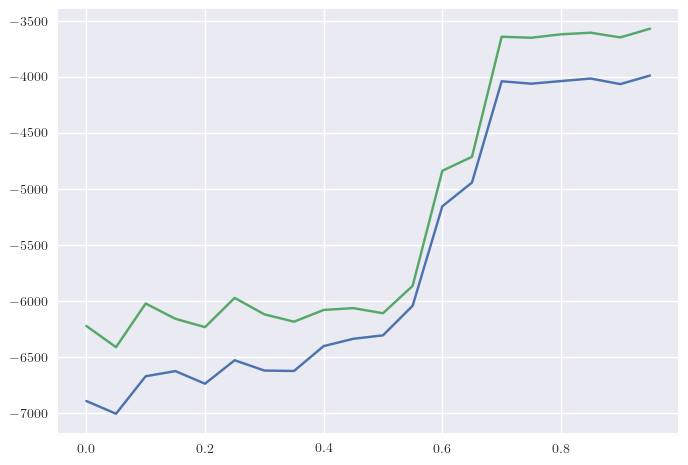

In [599]:
plt.plot(co2ls,load_imbalances_negative_vals[:,0])
plt.plot(co2ls,load_imbalances_negative_vals[:,1])

70857
47810
41936
41975
42357
39196
37071
37334
33713
33771
32092
30433
28700
28914
22030
21307
21273
21287
21269
21398


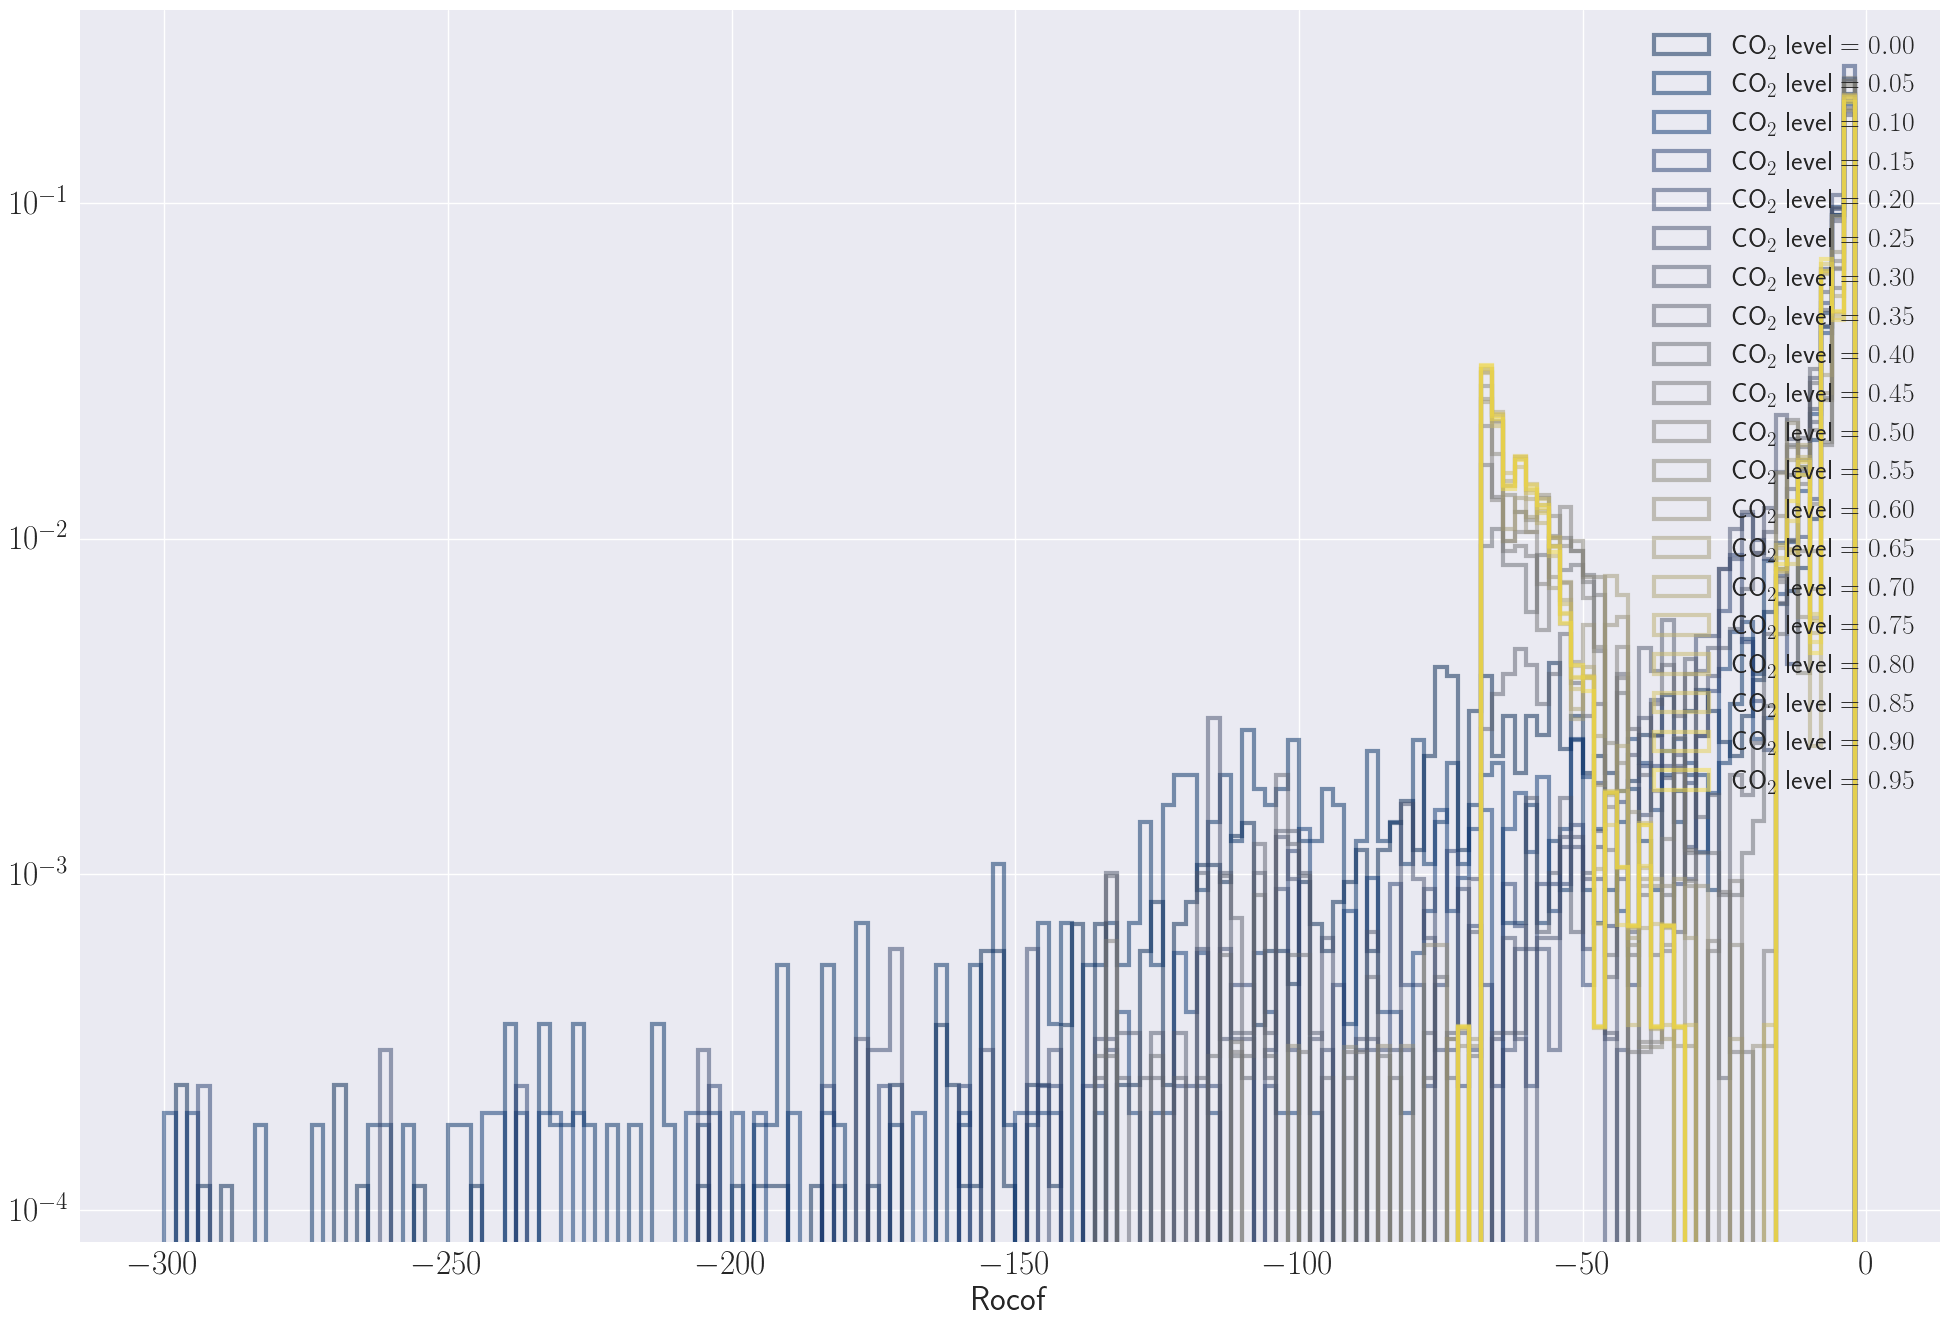

In [581]:
f,ax = plt.subplots(figsize = (24,16))#plt.subplots(5,2,figsize = (24,50))
cmap = plt.get_cmap('cividis')

for count,co2l in enumerate(co2ls):  
    bins = np.arange(-300,0,2)
    if len(RoCoF[count]):
        ax.hist(RoCoF[count],
                            bins = bins, 
                            histtype='step',
                            label = r'$\text{CO}_2\text{ level} = %.2f$'%co2l,
                                linewidth = 3,
                  color = cmap(count/len(co2ls)),
                  density = True,
               alpha = 0.5)   
        print(len(RoCoF[count]))
ax.set_xlabel(r'Rocof',fontsize = 24)
ax.tick_params(axis = 'both', which = 'both', labelsize = 24)
ax.set_yscale('log')
ax.legend(fontsize=20)
#ax[i].set_ylim([1,5e4])
#plt.savefig(save_path+'Europe_load_imbalance_and_inertia_proxies_step_histogram.pdf',bbox_inches = 'tight')
plt.show()

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/numpy/lib/histograms.py:905: RuntimeWarning: invalid value encountered in true_divide
  return n/db/n.sum(), bin_edges
<ipython-input-341-365cb898338c>:47: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax[i].set_yscale('log')
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/numpy/lib/histograms.py:905: RuntimeWarning: invalid value encountered in true_divide
  return n/db/n.sum(), bin_edges
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/numpy/lib/histograms.py:905: RuntimeWarning: invalid value encountered in true_divide
  return n/db/n.sum(), bin_edges
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/numpy/lib/histograms.py:905: RuntimeWarning: invalid value encountered in true_divide
  return n/db/n.sum(), bin_edges
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/numpy/lib/histograms.py:905: RuntimeWarning: inv

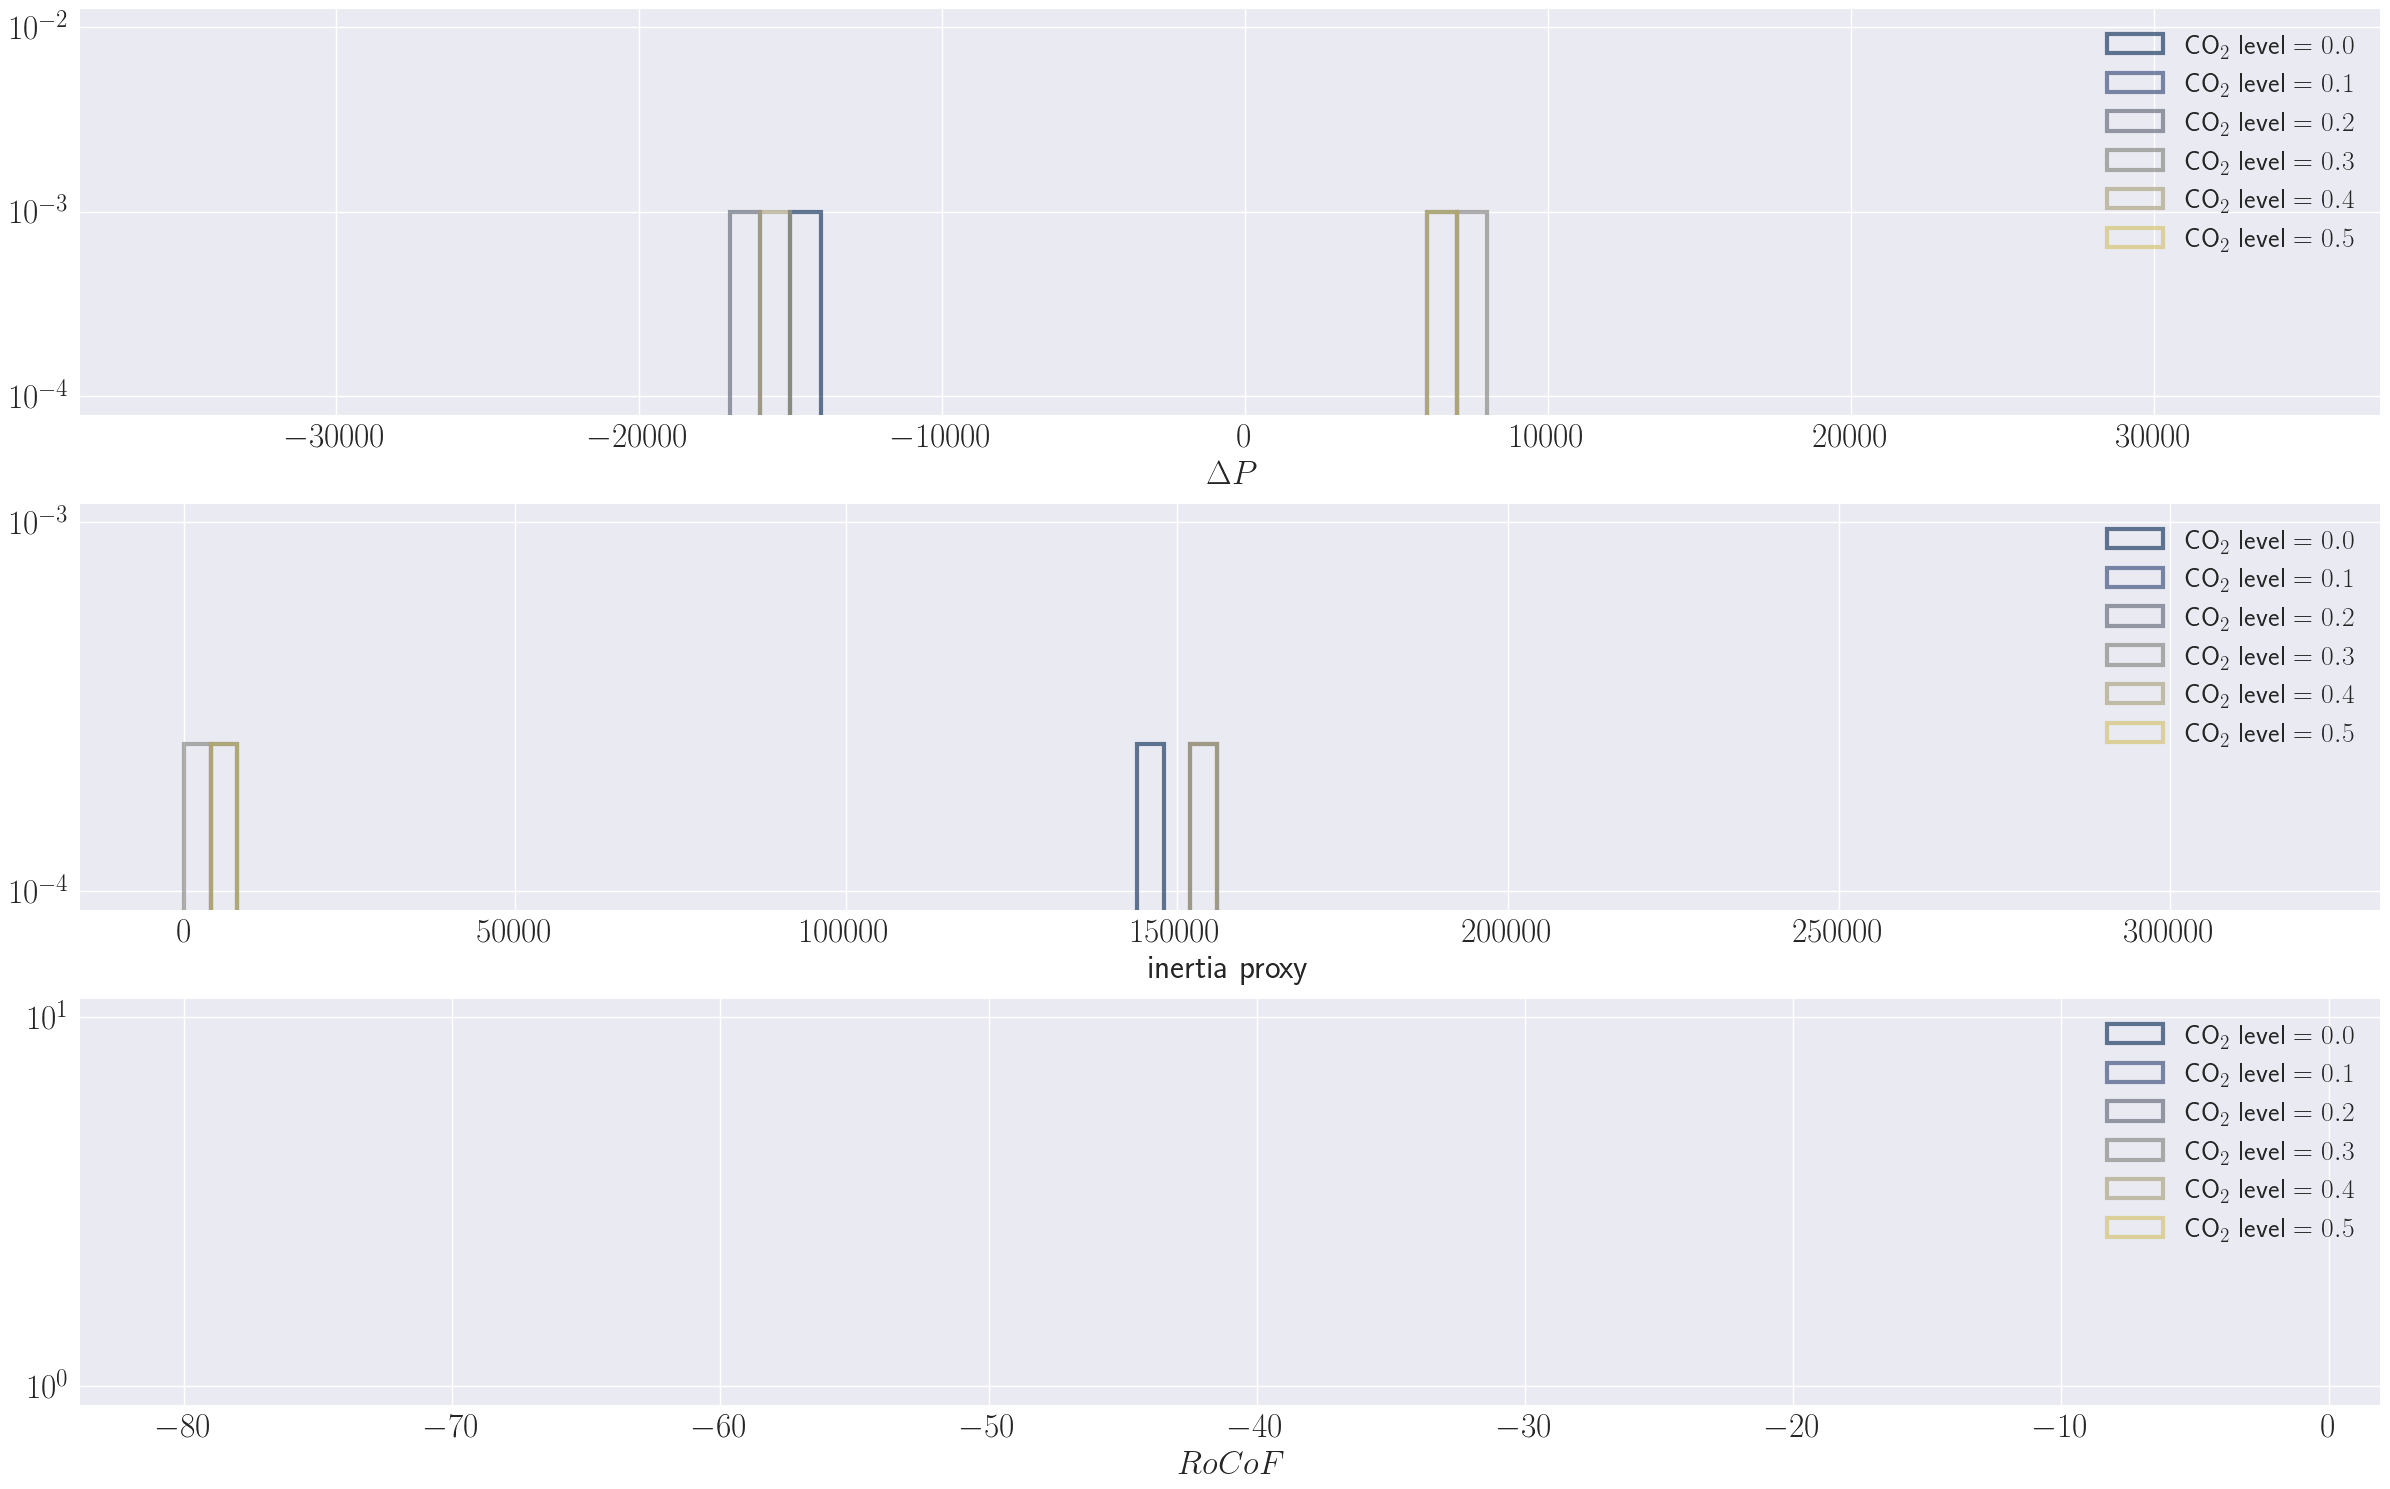

In [341]:
f,ax = plt.subplots(3,figsize = (24,15))#plt.subplots(5,2,figsize = (24,50))

cmap = plt.get_cmap('cividis')

for count,co2l in enumerate(co2ls):
    maxval = int(3.5e4)
    bins = np.arange(-maxval,maxval,1000)
    #ax[count].hist(RoCoF.flatten(),bins = bins, label = r'$\text{CO}_2\text{ level} = %.1f$'%co2l)#i//2,i%2
    ax[0].hist(load_imbalances[count],
                        bins = bins, 
                        histtype='step',
                        label = r'$\text{CO}_2\text{ level} = %.1f$'%co2l,
              linewidth = 3,
              color = cmap(count/6),
              density = True,
              alpha = 0.6)
    ax[0].set_xlabel(r'$\Delta P$',
                            fontsize = 24)
    
    maxval = int(3.2e5)
    bins = np.arange(0,maxval,4000)
    
    ax[1].hist(inertia_proxies[count],
                        bins = bins, 
                        histtype='step',
                        label = r'$\text{CO}_2\text{ level} = %.1f$'%co2l,
                            linewidth = 3,
              color = cmap(count/6),
              density = True,
              alpha = 0.6)   
    ax[1].set_xlabel(r'inertia proxy',
                            fontsize = 24)
    
    RoCoFs_current = (np.array(RoCoF[count])*50/2/6).flatten()
    bins = np.arange(-80,0,2)#np.arange(-200,300,2.5)
    ax[2].hist(RoCoFs_current,bins = bins, 
               label = r'$\text{CO}_2\text{ level} = %.1f$'%co2l,
               histtype='step',
               linewidth = 3,
               color = cmap(count/6),
               density = True,
              alpha = 0.6)
    ax[2].set_xlabel(r'$RoCoF$',
                           fontsize = 24)
    for i in range(3):
        ax[i].tick_params(axis = 'both', which = 'both', labelsize = 24)
        ax[i].set_yscale('log')
        ax[i].legend(fontsize=20)
        #ax[i].set_ylim([1,5e4])
plt.tight_layout()
#plt.savefig(save_path+'Europe_load_imbalance_and_inertia_proxies_step_histogram.pdf',bbox_inches = 'tight')
plt.show()

In [224]:
print(np.max(load_imbalances))

25857.09953436005


## Calculate inertia over time

In [497]:
def calc_system_inertia_over_time(pypsa_network,
                                  snet_index = None,
                                  use_pnom = True,
                                  inertiaplants = None, 
                                  inertia_storages = None):
    """get inertia generation for a subgraph"""      
        
    Graph              = utils.build_networkx_graph(pypsa_network,snet_index = snet_index)
    
    inertia_over_time = np.zeros(len(pypsa_network.snapshots))
    
    for count,timestamp in enumerate(pypsa_network.snapshots):
        
        # Rescale load shedding since units for load shedding are different
        # than for generation, storage and load
        load_shedding_indices = pypsa_network.generators[pypsa_network.generators.carrier.isin(['load'])].index

        current_generation = pypsa_network.generators_t.p.loc[timestamp].copy()
        current_generation[load_shedding_indices] /= 1e3
        current_storage    = pypsa_network.storage_units_t.p.loc[timestamp]
        
        
        inertia_over_time[count] = utils.get_inertia_gen_subgraph(Graph,
                                                          pypsa_network.generators,
                                                          current_generation,
                                                          pypsa_network.storage_units,
                                                          current_storage,
                                                           use_pnom,
                                                          inertiaplants = inertiaplants,
                                                          inertia_storages = inertia_storages)
    
    return inertia_over_time

In [501]:
current_co2ls = [0.0,0.2,0.4,0.6,0.8]
inertia_time = np.zeros((len(current_co2ls),len(network.snapshots)))

for i, co2l in enumerate(current_co2ls):
    
    level = np.round(co2l,2)
    network = pypsa.Network()
    network.import_from_netcdf(path_to_pypsa_network+f'elec_s_800_ec_lv1.0_Co2L{level}-3H.nc')  
    
    inertia_time[i] = calc_system_inertia_over_time(network,snet_index = 0)

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.0-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this wil

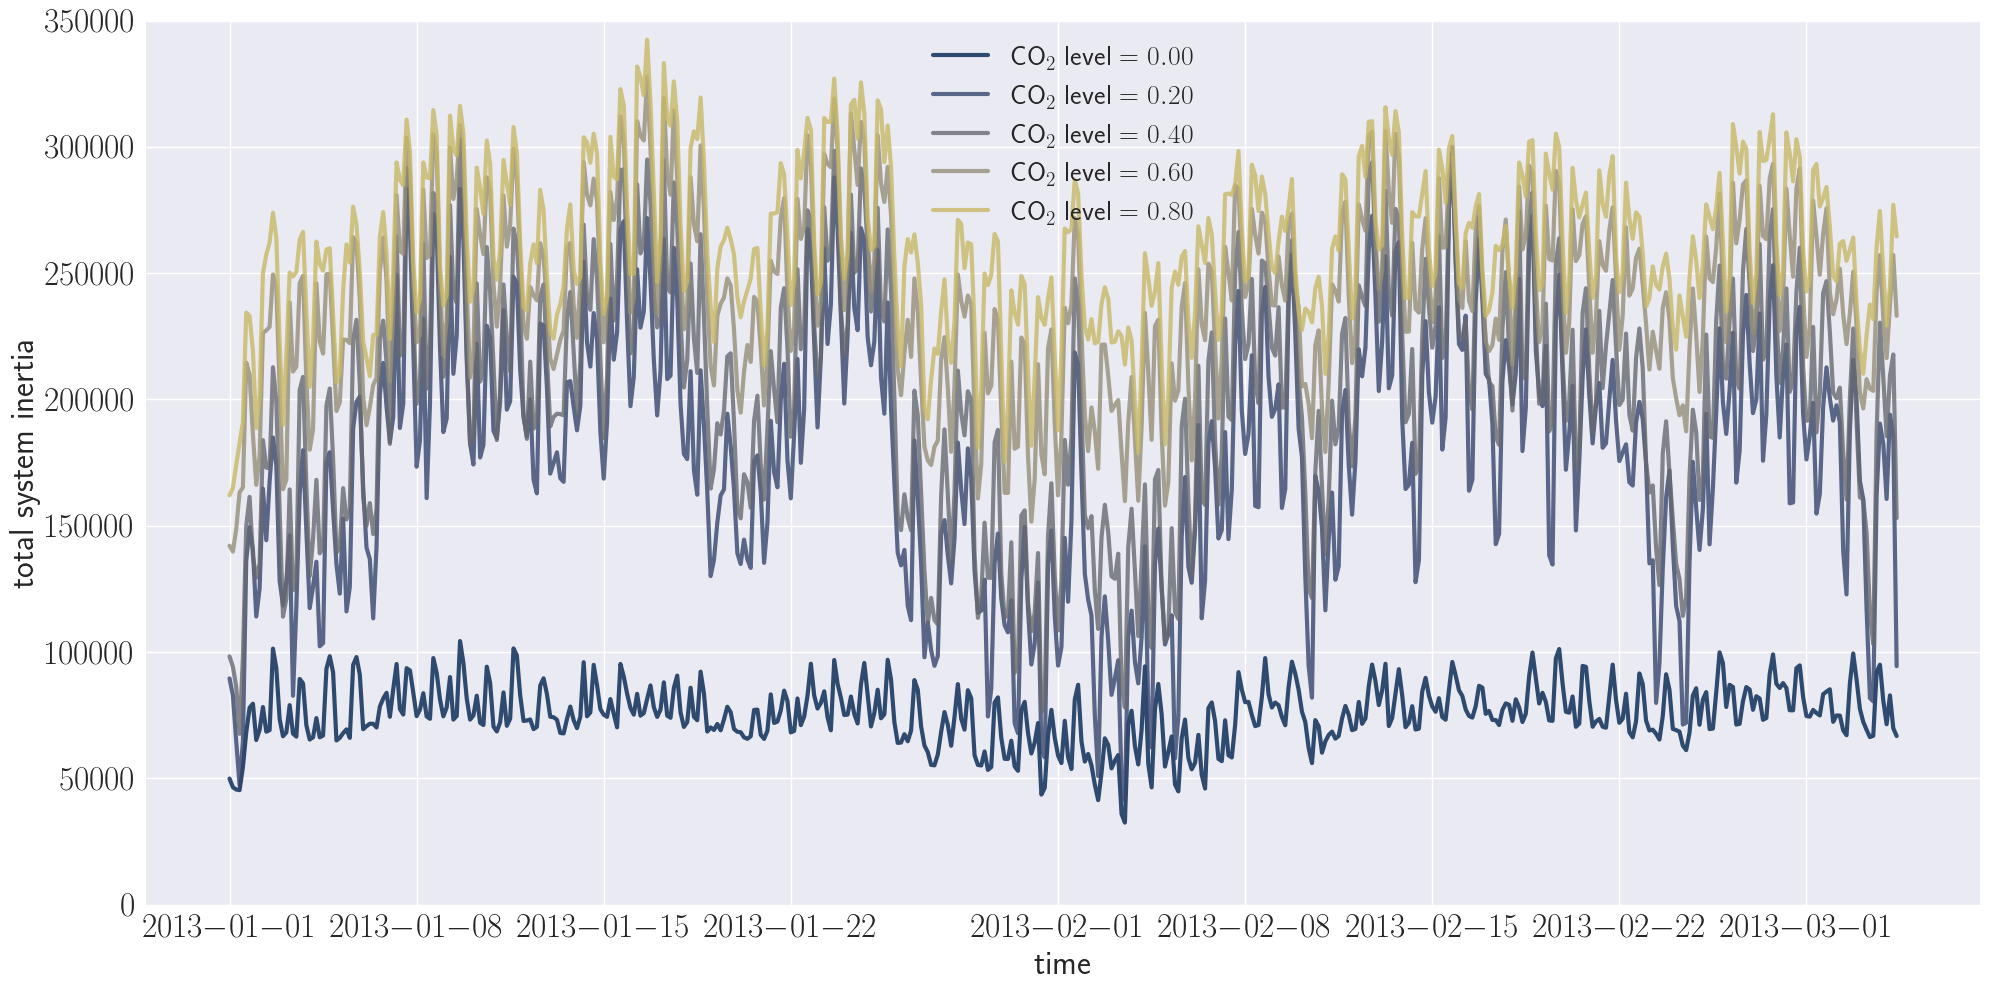

In [524]:
mpl.style.use('seaborn')
f,ax = plt.subplots(figsize=(20,10))
cmap = plt.get_cmap('cividis')
for i,co2l in enumerate(current_co2ls):
    ax.plot(network.snapshots[:500],inertia_time[i][:500],
            color =cmap(i/len(current_co2ls)),
            lw = 3,
           alpha = 0.8,
            label = r'$\text{CO}_2\text{ level} = %.2f$'%co2l)
ax.legend(fontsize = 20)
ax.tick_params(axis = 'both', which = 'both', labelsize = 24)
ax.set_ylabel('total system inertia',fontsize = 24)
ax.set_xlabel('time',fontsize = 24)

ax.set_ylim([0,3.5e5])
plt.tight_layout()
plt.savefig(save_path+'Europe_Total_system_inertia_over_time.pdf',bbox_inches = 'tight')

plt.show()

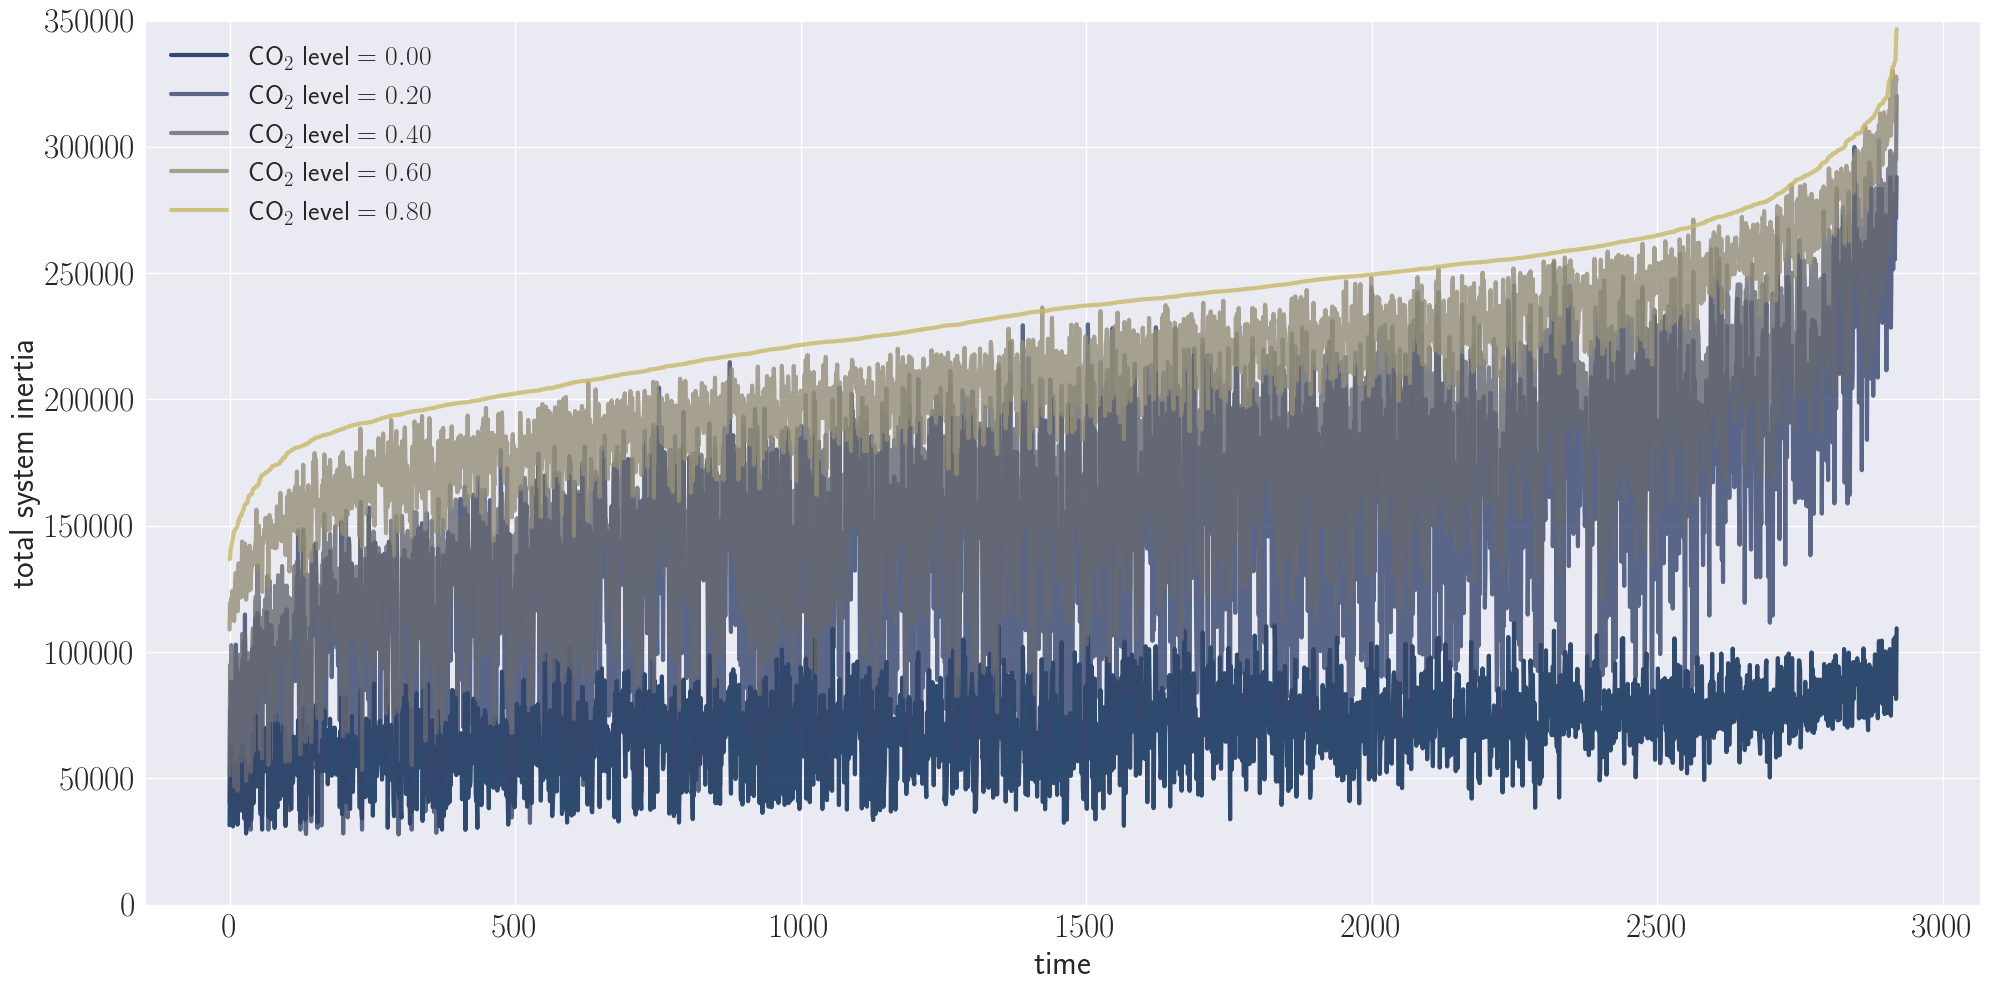

In [536]:
indices = np.argsort(inertia_time[-1])

f,ax = plt.subplots(figsize=(20,10))
cmap = plt.get_cmap('cividis')
for i,co2l in enumerate(current_co2ls):
    ax.plot(np.arange(len(network.snapshots)),inertia_time[i][indices],
            color =cmap(i/len(current_co2ls)),
            lw = 3,
           alpha = 0.8,
            label = r'$\text{CO}_2\text{ level} = %.2f$'%co2l)
ax.legend(fontsize = 20)
ax.tick_params(axis = 'both', which = 'both', labelsize = 24)
ax.set_ylabel('total system inertia',fontsize = 24)
ax.set_xlabel('time',fontsize = 24)

ax.set_ylim([0,3.5e5])
plt.tight_layout()

In [567]:
print(len(network.snapshots))

2920


146


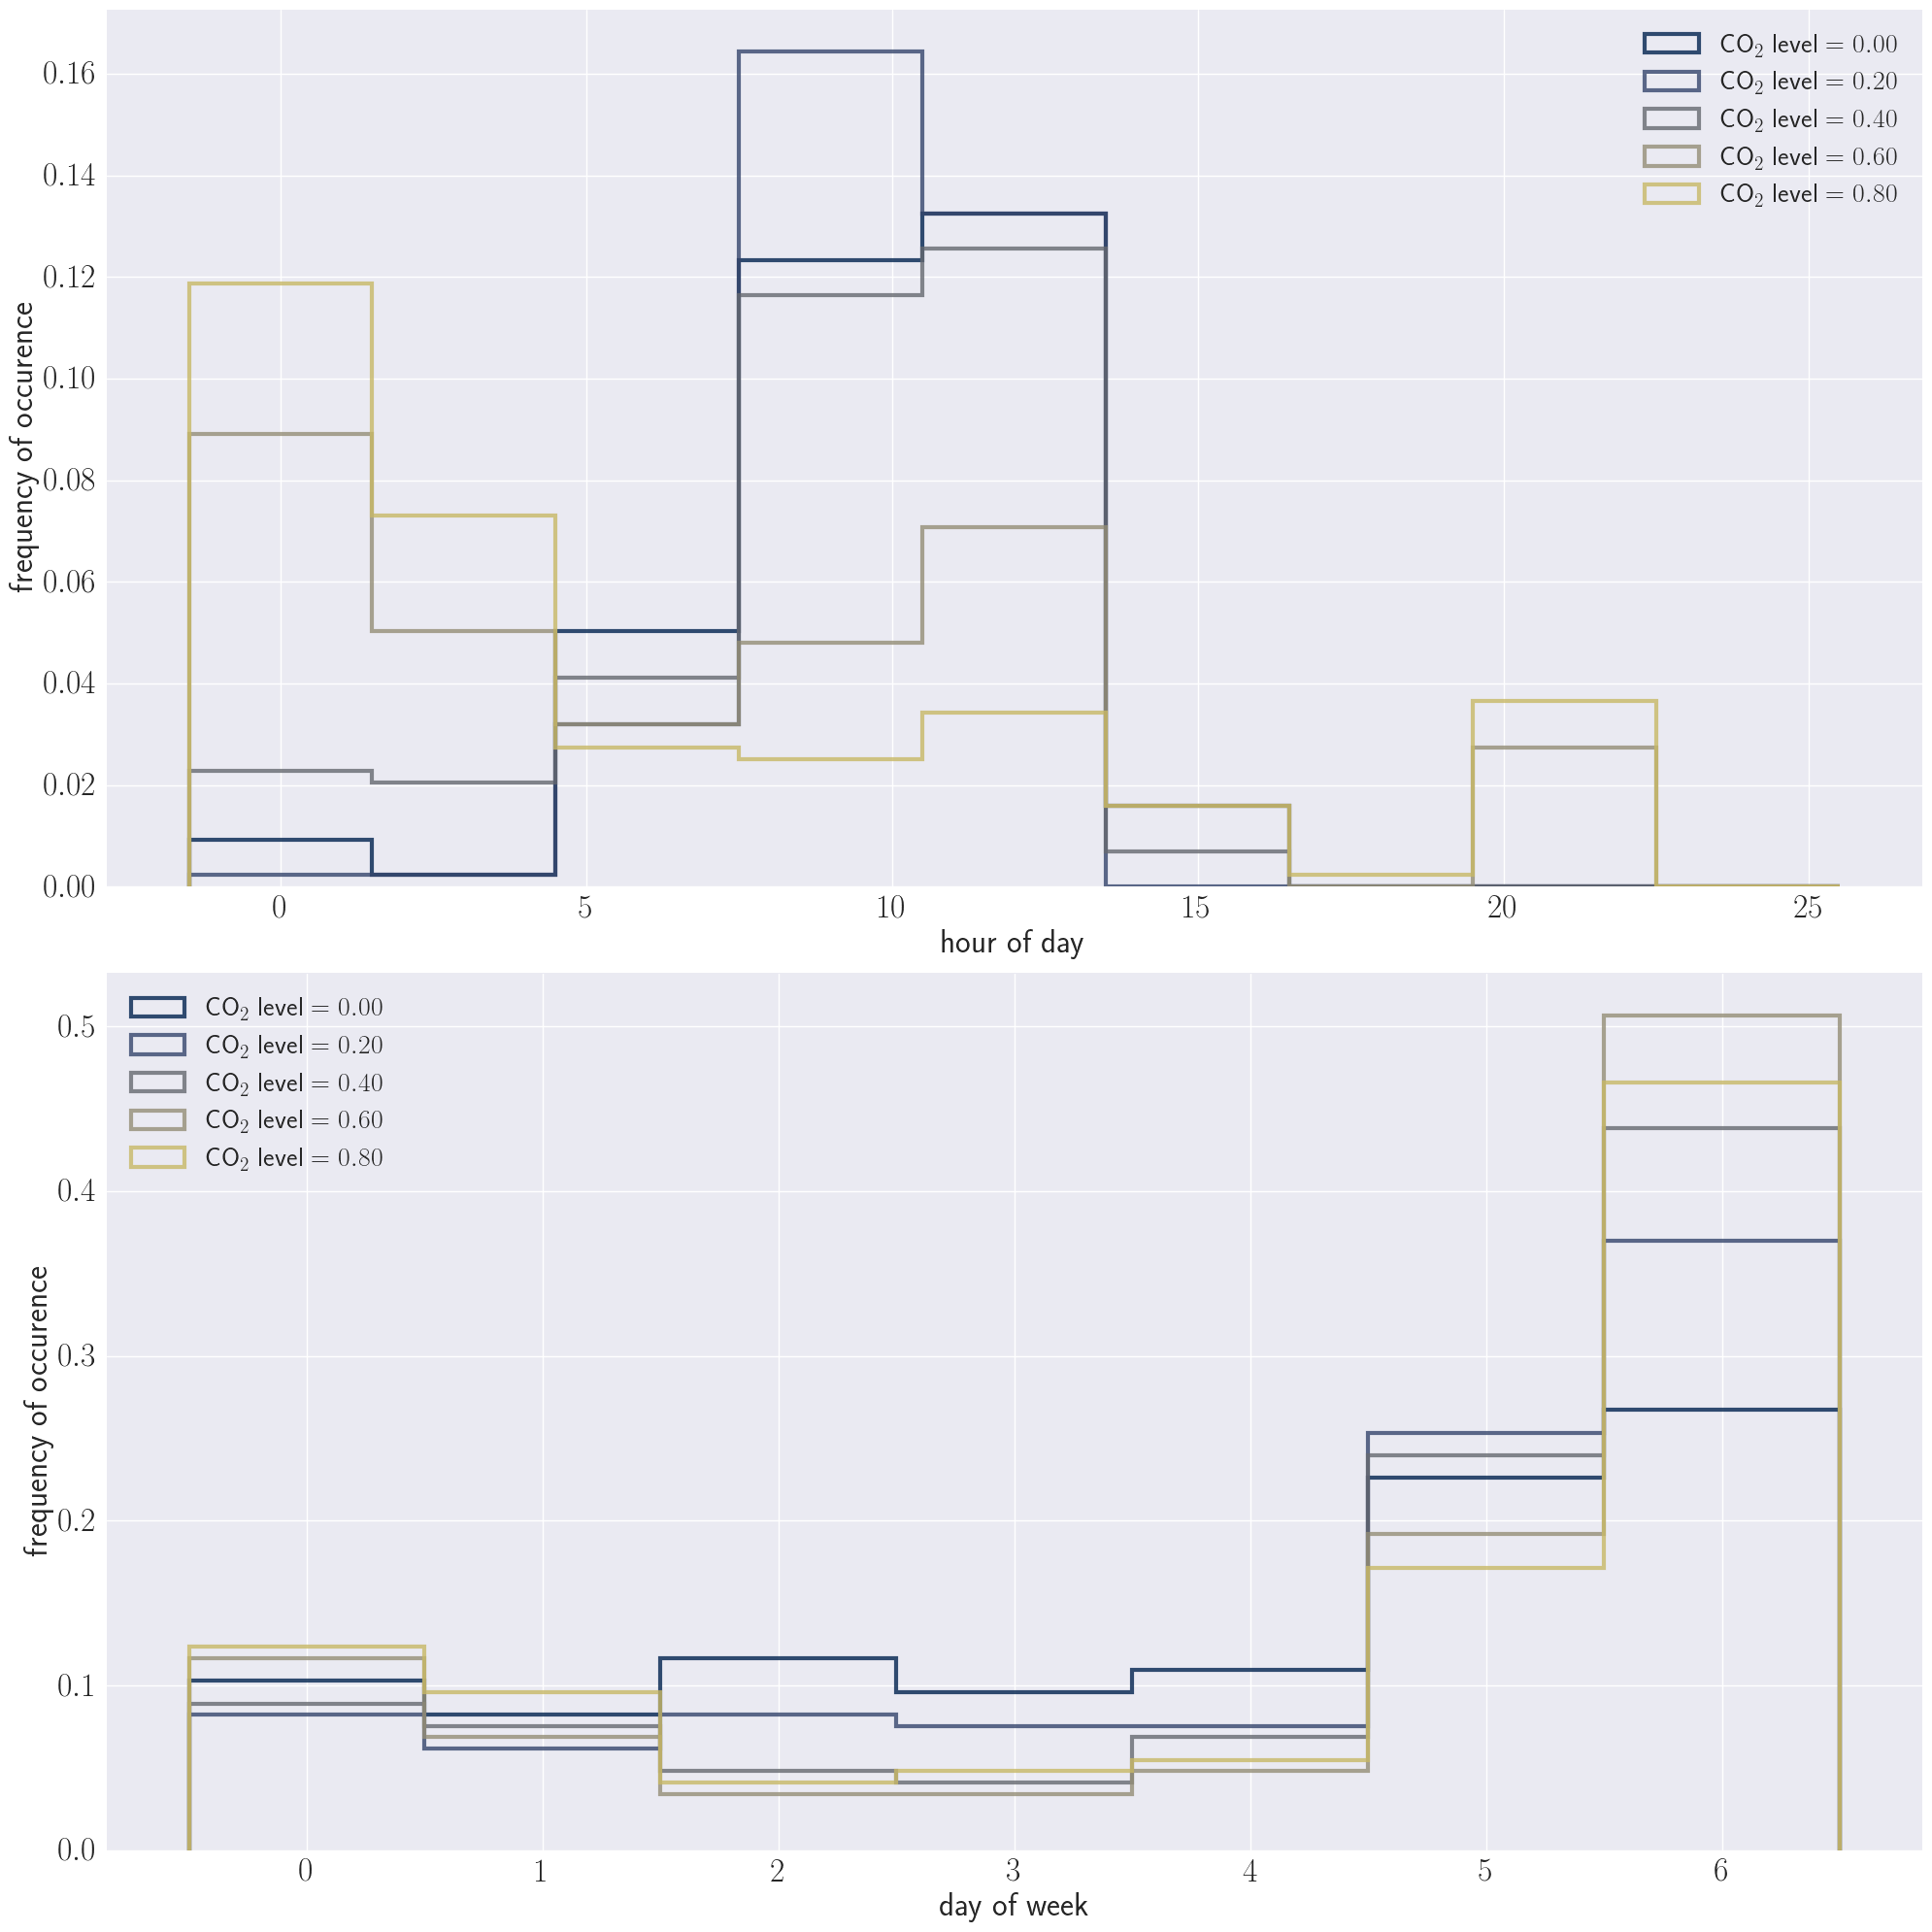

In [600]:
minimal_snapshots = []
nof_snapshots = int(0.05*len(network.snapshots))
print(nof_snapshots)
f,ax = plt.subplots(2,1,figsize=(20,20))
for i,co2l in enumerate(current_co2ls):
    indices = np.argsort(inertia_time[i])
    minimal_snapshots.append(network.snapshots[indices][:nof_snapshots])
    
    bins = np.arange(-1.5,26.5,3)

    ax[0].hist(minimal_snapshots[i].hour,
                bins = bins, 
                histtype='step',
                label = r'$\text{CO}_2\text{ level} = %.2f$'%co2l,
                linewidth = 3,
                color = cmap(i/len(current_co2ls)),
                density = True,
               alpha = 0.8)  
    ax[0].set_xlabel('hour of day',fontsize = 24)

    #bins = np.arange(-0.5,13.5,1)
    bins = np.arange(-0.5,7.5,1)
    ax[1].hist(minimal_snapshots[i].weekday,
                bins = bins, 
                histtype='step',
                label = r'$\text{CO}_2\text{ level} = %.2f$'%co2l,
                linewidth = 3,
                color = cmap(i/len(current_co2ls)),
                density = True,
               alpha = 0.8)  
    
    ax[1].set_xlabel('day of week',fontsize = 24)

for i in range(2):
    if i == 0:
        ax[i].legend(fontsize = 20,loc = 'best')
    else:
        ax[i].legend(fontsize = 20,loc = 2)

    ax[i].tick_params(axis = 'both', which = 'both', labelsize = 24)
    ax[i].set_ylabel('frequency of occurence',fontsize = 24)
plt.tight_layout()
#plt.savefig(save_path+'Europe_times with_small_system_inertia.pdf',bbox_inches = 'tight')


In [580]:
print(minimal_snapshots[-1].hour)

Int64Index([12,  3,  6,  0,  0,  3, 12,  3, 12,  6,  0,  3,  0, 21,  9, 15,  0,
             6,  3,  0,  3, 12,  0,  3,  0,  0, 15,  0,  0,  9,  0,  3,  0,  0,
             9,  0, 12, 12, 12, 12, 21,  0,  9,  3,  3, 21, 21,  0,  6, 21,  0,
            21,  0,  0,  9, 21, 21, 12,  3,  3, 15, 21,  3,  0,  0,  0,  3,  0,
             9,  0,  3,  0, 12,  3,  3,  0,  6,  0, 15, 12,  0,  6,  6, 15,  6,
             0,  0,  3, 15,  0, 21,  0,  0,  3,  0, 21,  0,  3,  9,  6],
           dtype='int64', name='name')


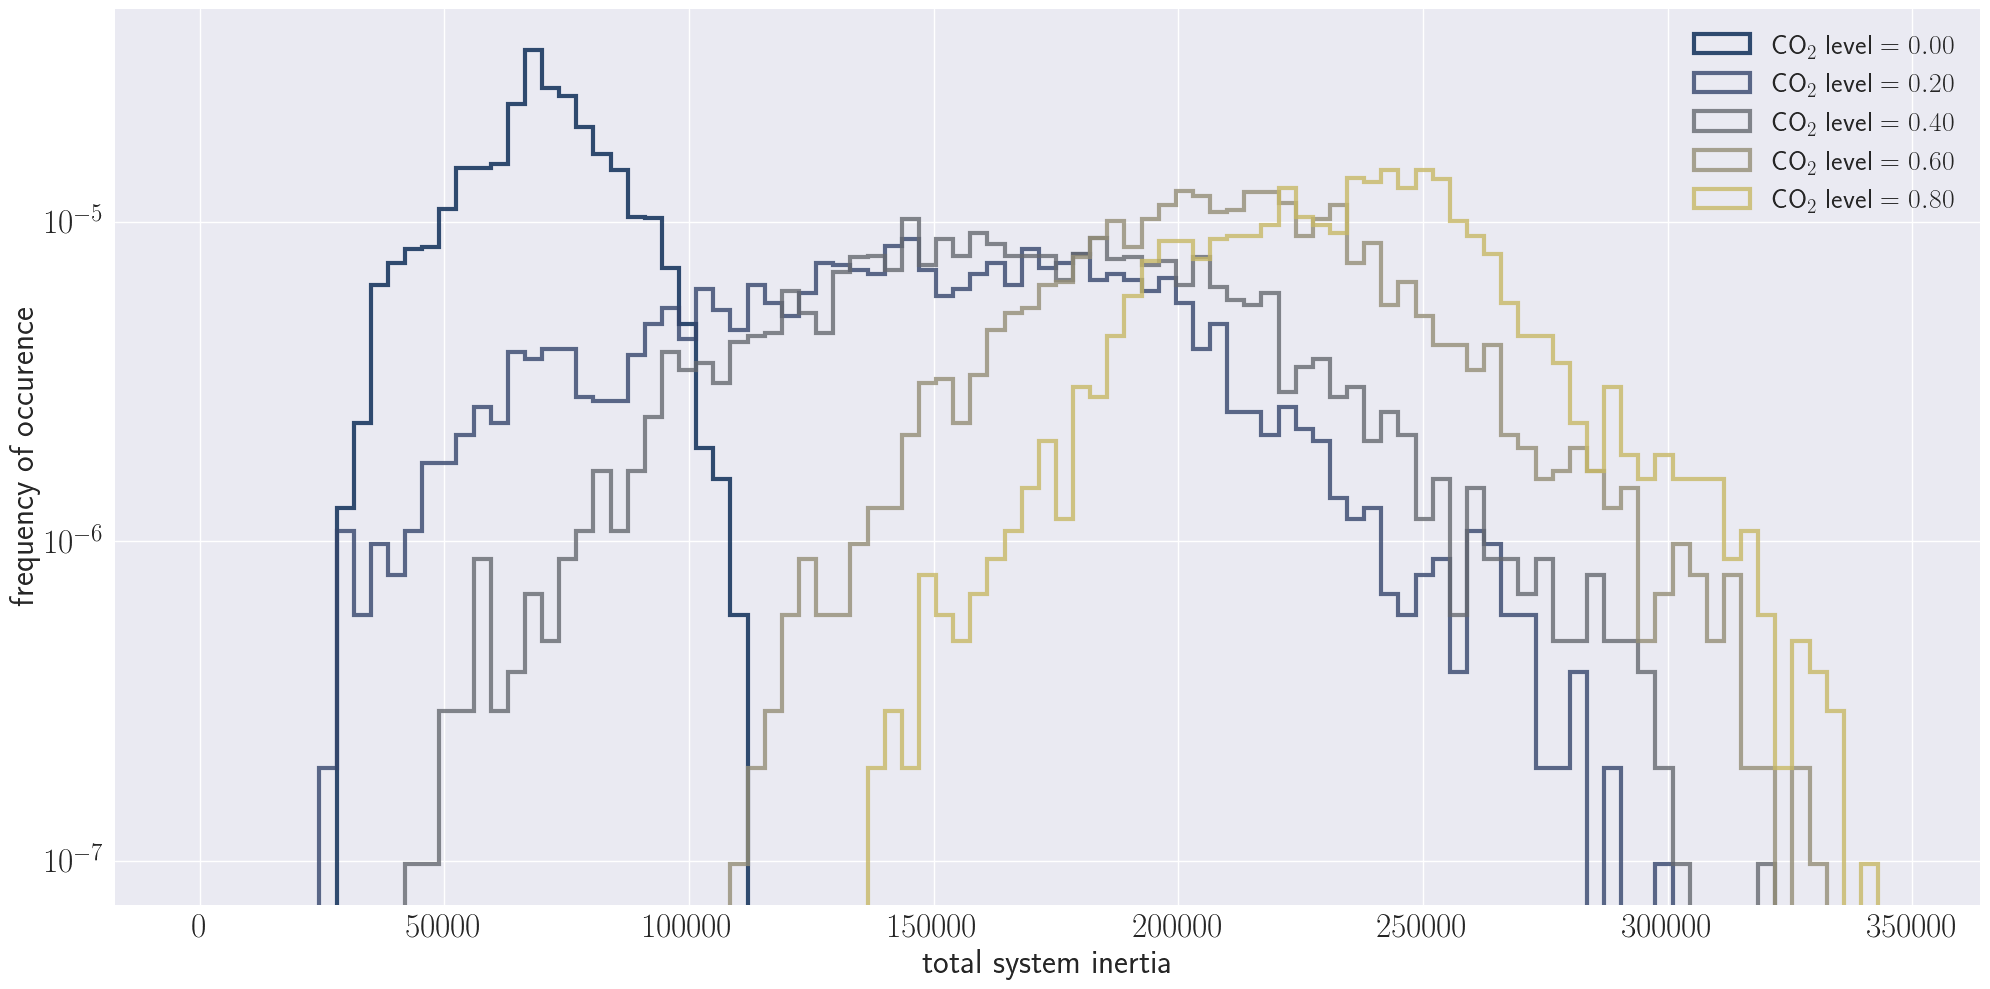

In [534]:
mpl.style.use('seaborn')

f,ax = plt.subplots(figsize=(20,10))
cmap = plt.get_cmap('cividis')
bins = np.arange(0,3.5e5,3.5e3)
for i,co2l in enumerate(current_co2ls):
    ax.hist(inertia_time[i],
                 bins = bins, 
                histtype='step',
                label = r'$\text{CO}_2\text{ level} = %.2f$'%co2l,
                linewidth = 3,
            color = cmap(i/len(current_co2ls)),
                  density = True,
               alpha = 0.8)   
ax.legend(fontsize = 20)
ax.tick_params(axis = 'both', which = 'both', labelsize = 24)
ax.set_xlabel('total system inertia',fontsize = 24)
ax.set_ylabel('frequency of occurence',fontsize = 24)
ax.set_yscale('log')
#ax.set_ylim([0,3.5e5])
plt.tight_layout()
plt.savefig(save_path+'Europe_Total_system_inertia_over_time_hist.pdf',bbox_inches = 'tight')

plt.show()

In [487]:
reduced_gens

,p_nom_max,weight,p_nom,capital_cost,carrier,marginal_cost,bus,p_nom_extendable,efficiency,control,...,start_up_cost,shut_down_cost,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down
name,,,,,,,,,,,,,,,,,,,,,
AL0 0 offwind-ac,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AL0 0 onwind,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AL0 0 solar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AT0 0 CCGT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AT0 0 OCGT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SK0 5 onwind,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SK0 5 ror,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SK0 5 solar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Following is evaluation for German grid

In [156]:
path_to_pypsa_network   = path + 'Data/system_split/Data/'
path_to_cascade_results = path + 'Data/system_split/Data/'

### load network data
year            = 2014
number_of_nodes = 306

network = pypsa.Network()
network.import_from_netcdf(path_to_pypsa_network+\
                           str(year)+\
                           '/elec_s_'+\
                           str(number_of_nodes)+\
                           '_ec_lv1.0_1H.nc')

network.determine_network_topology()

branches = network.branches()

branches = branches[["bus0","bus1","x_pu_eff","s_nom"]]
Graph = utils.build_networkx_graph(branches)

### read in cascade results
splitting_cascades = pickle.load(open(path_to_cascade_results+str(year)+\
                                      '/system_splits_'+\
                                      str(year)+\
                                      '_'+\
                                      str(number_of_nodes)+\
                                      '_edge_based.pickle','rb'))

### calculate load imbalance and inertia proxy using "load" criterion 
### (i.e. no split component contains more than 90 % of generation or load)

use_pnom  = True
criterion = 'load'

solution_dict = {}

for key in splitting_cascades.keys():
    timestamp = utils.solution_key_to_pandas_timestamp(key)
    solution_dict[key] = []
    splits = splitting_cascades[key]
    print(key)
    for i,split in enumerate(splits):
        results = utils.evaluate_split_observables(split,
                                                   network,
                    ipynb                               timestamp,
                                                   use_pnom = use_pnom,
                                                   criterion = 'load')
        if results['inertia_proxy']:
            solution_dict[key].append(i)
            solution_dict[key].append(results)



Importing PyPSA from older version of PyPSA than current version 0.17.1.
Please read the release notes at https://pypsa.org/doc/release_notes.html
carefully to prepare your network for import.

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_306_ec_lv1.0_1H.nc has buses, carriers, generators, lines, loads, storage_units


01_01_2014_00
01_01_2014_01
01_01_2014_02
01_01_2014_03
01_01_2014_04
01_01_2014_05
01_01_2014_06
01_01_2014_07
01_01_2014_08


KeyboardInterrupt: 

In [ ]:
#save_path = path + 'Data/system_split/Data/'
#
#pickle.dump(solution_dict,
#             open(save_path+'Germany_'+\
#                  str(number_of_nodes)+\
#                  '_split_evaluation_'+\
#                  str(year)+\
#                  '_load_based.pickle','wb'))

### Calc Rocof

In [54]:
nof_splits = 0
RoCoF = []
load_imbalances = []
inertia_proxies = []
for key in solution_dict.keys():
    for j in range(len(solution_dict[key]))[1::2]:
        for k in range(len(solution_dict[key][j]['load_imbalance'])):
            RoCoF.append(solution_dict[key][j]['load_imbalance'][k]/solution_dict[key][j]['inertia_proxy'][k])
            load_imbalances.append(solution_dict[key][j]['load_imbalance'][k])
            inertia_proxies.append(solution_dict[key][j]['inertia_proxy'][k])

        nof_splits += 1
        #load_imbalances.append(np.abs(solution_dict[key][j]['load_imbalance'][0]))
        #inertia_proxies.append(np.abs(solution_dict[key][j]['inertia_proxy'][0]))  
        #load_imbalances[i].append(np.abs(solution_dict[key][j]['load_imbalance'][1]))
        #inertia_proxies[i].append(np.abs(solution_dict[key][j]['inertia_proxy'][1]))
                
                
RoCoF = np.array(RoCoF)*50/2/6
print(np.min(RoCoF[~np.isinf(RoCoF)]))
maxval = np.round(np.max(np.abs(RoCoF)[~np.isinf(RoCoF)]),-1)

-1082.7460941086804


/home/fkaiser/.conda/envs/fkaiser/lib/python3.7/site-packages/ipykernel_launcher.py:8: RuntimeWarning: divide by zero encountered in double_scalars
  


## Plot Rocof distribution for all years

Importing PyPSA from older version of PyPSA than current version 0.17.1.
Please read the release notes at https://pypsa.org/doc/release_notes.html
carefully to prepare your network for import.

INFO:pypsa.io:Imported network elec_s_306_ec_lv1.0_1H.nc has buses, carriers, generators, lines, loads, storage_units
/home/fkaiser/.conda/envs/fkaiser/lib/python3.7/site-packages/ipykernel_launcher.py:40: RuntimeWarning: divide by zero encountered in double_scalars
Importing PyPSA from older version of PyPSA than current version 0.17.1.
Please read the release notes at https://pypsa.org/doc/release_notes.html
carefully to prepare your network for import.

INFO:pypsa.io:Imported network elec_s_306_ec_lv1.0_1H.nc has buses, carriers, generators, lines, loads, storage_units
Importing PyPSA from older version of PyPSA than current version 0.17.1.
Please read the release notes at https://pypsa.org/doc/release_notes.html
carefully to prepare your network for import.

INFO:pypsa.io:Imported network el

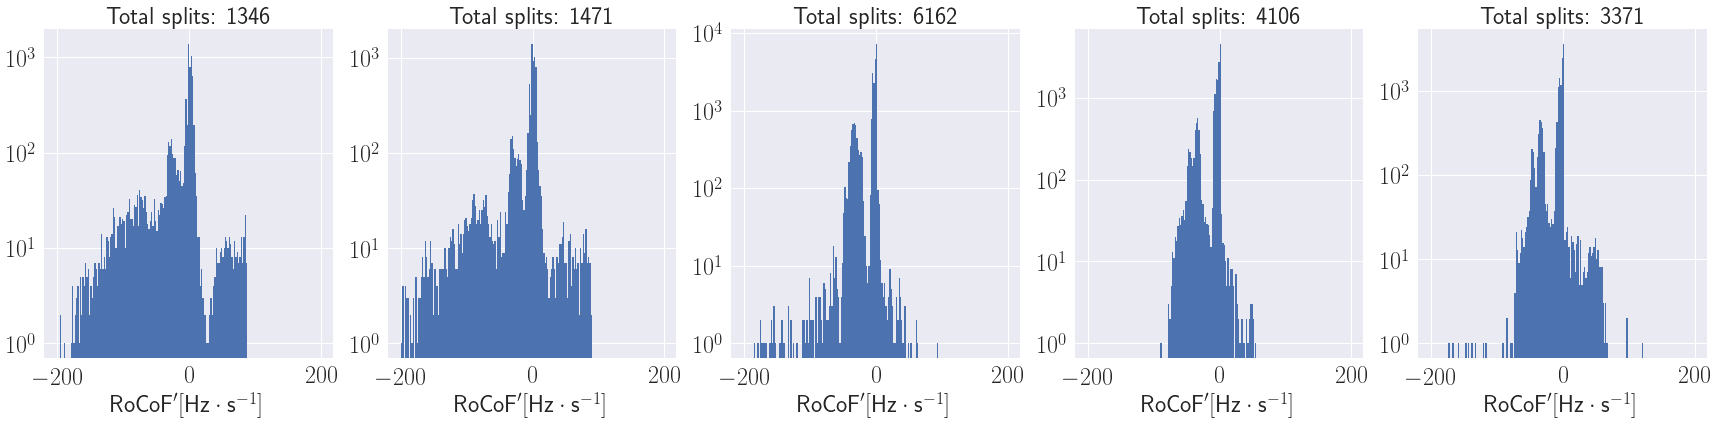

In [18]:
mpl.style.use('seaborn')
plt.rc('text', usetex = True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

path_to_pypsa_network   = path + 'Data/system_split/Data/'
path_to_cascade_results = path + 'Data/system_split/Data/'


f,ax = plt.subplots(1,5,figsize = (24,6))#plt.subplots(5,2,figsize = (24,50))

years = [2013,2014,2015,2016,2018]

for i,year in enumerate(years):
    network = pypsa.Network()
    network.import_from_netcdf(path_to_pypsa_network+\
                               str(year)+\
                               '/elec_s_'+\
                               str(number_of_nodes)+\
                               '_ec_lv1.0_1H.nc')
    
    network.determine_network_topology()
    
    branches = network.branches()
    
    branches = branches[["bus0","bus1","x_pu_eff","s_nom"]]
    Graph = utils.build_networkx_graph(branches)
    
    splitting_cascades = pickle.load(open(path_to_cascade_results+str(year)+\
                                          '/system_splits_'+\
                                          str(year)+\
                                          '_'+\
                                          str(number_of_nodes)+\
                                          '_edge_based.pickle','rb'))
    
    solution_dict = pickle.load(
                 open(path_to_cascade_results+str(year)+'/Germany_'+\
                      str(number_of_nodes)+\
                      '_split_evaluation_'+\
                      str(year)+\
                      '_load_based.pickle','rb'))
    
    nof_splits = 0
    RoCoF = []
    load_imbalances = []
    inertia_proxies = []
    for key in solution_dict.keys():
        for j in range(len(solution_dict[key]))[1::2]:
            for k in range(len(solution_dict[key][j]['load_imbalance'])):
                RoCoF.append(solution_dict[key][j]['load_imbalance'][k]/solution_dict[key][j]['inertia_proxy'][k])
                load_imbalances.append(solution_dict[key][j]['load_imbalance'][k])
                inertia_proxies.append(solution_dict[key][j]['inertia_proxy'][k])
    
            nof_splits += 1    
    RoCoF = (np.array(RoCoF)*50/2/6).flatten()
    maxval = 200
    bins = np.arange(-maxval,maxval,2)
    ax[i].hist(RoCoF.flatten(),bins = bins)#i//2,i%2
    ax[i].tick_params(axis = 'both', which = 'both', labelsize = 24)
    ax[i].set_yscale('log')
    ax[i].set_xlabel(r'$\text{RoCoF}^\prime  [\text{Hz} \cdot \text{s}^{-1}]$',fontsize = 24)
    ax[i].set_title('Total splits: %i'%nof_splits, fontsize = 24)
    #bins = np.arange(-1e5,1e5,500)
    #ax[i,0].hist(load_imbalances,bins = bins)#i//2,i%2
    #ax[i,0].tick_params(axis = 'both', which = 'both', labelsize = 24)
    #ax[i,0].set_yscale('log')
    #ax[i,0].set_xlim([-2e4,2e4])
    #ax[i,0].set_xlabel(r'$\Delta P$',fontsize = 24)
    #ax[i,0].scatter([],[],s = 0,label = '%i'%year,color = 'C0')
    #ax[i,0].legend(fontsize = 24)
    #ax[i,0].set_title('Total splits: %i'%nof_splits, fontsize = 24)
    #
    #bins = np.arange(0,1e6,500)
    #
    #ax[i,1].hist(inertia_proxies,bins = bins)#i//2,i%2
    #ax[i,1].tick_params(axis = 'both', which = 'both', labelsize = 24)
    #ax[i,1].set_yscale('log')
    #ax[i,1].set_xlim([0,1e5])
    #ax[i,1].set_xlabel(r'inertia proxies',fontsize = 24)
    #ax[i,1].scatter([],[],s = 0,label = '%i'%year,color = 'C0')
    #ax[i,1].legend(fontsize = 24)
    #ax[i,1].set_title('Total splits: %i'%nof_splits, fontsize = 24)
plt.tight_layout()
#plt.savefig(save_path+'inertias_and_load_imbalances_Germany.pdf')

## Compare likely splits for different co2levels

In [447]:
co2l = 0.5

path_to_pypsa_network   = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/'
results_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/Results/'

network = pypsa.Network()
network.import_from_netcdf(path_to_pypsa_network+f'elec_s_800_ec_lv1.0_Co2L{co2l}-3H.nc')
snet_index = 0

G = utils.build_networkx_graph(network, snet_index = snet_index)

criterion = 'nodes'
splitting_cascades = pickle.load(open(results_path+f'system_splits_Co2L{co2l}.pickle','rb'))
solution_dict = pickle.load(open(results_path+f'Europe_Co2L{co2l}_split_evaluation_'+criterion+'_based_snet_%i'%snet_index+'.pickle','rb'))

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.5-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


In [449]:
 total_number_of_components = 0

for time_stamp in solution_dict.keys():
    if not solution_dict[time_stamp]:
        continue
    for i, split_number in enumerate(solution_dict[time_stamp][::2]):
        component_props = solution_dict[time_stamp][i*2+1]
        total_number_of_components += len(component_props['inertia_proxy'])

In [450]:
n_subset_solutions = -1

if n_subset_solutions==-1:
    indicator_vectors, component_props = visualisation.indicator_vectors_from_rocof_solution(solution_dict, splitting_cascades, G, criterion=criterion)
else:
    subset_of_keys = np.random.choice(list(solution_dict.keys()), n_subset_solutions, replace=False)
    subset_solution_dict = {key: solution_dict[key] for key in subset_of_keys}
    indicator_vectors, component_props = visualisation.indicator_vectors_from_rocof_solution(subset_solution_dict, splitting_cascades, G, criterion=criterion)

100%|██████████| 2920/2920 [11:17<00:00,  4.31it/s]


## Calculate likelihoods (as in example files)

In [49]:
path_to_pypsa_network   = path + 'Data/system_split/Data/'
path_to_cascade_results = path + 'Data/system_split/Data/'


year            = 2013
number_of_nodes = 306

network = pypsa.Network()
network.import_from_netcdf(path_to_pypsa_network+\
                           str(year)+\
                           '/elec_s_'+\
                           str(number_of_nodes)+\
                           '_ec_lv1.0_1H.nc')

network.determine_network_topology()

branches = network.branches()

branches = branches[["bus0","bus1","x_pu_eff","s_nom"]]
Graph = utils.build_networkx_graph(branches)

splitting_cascades = pickle.load(open(path_to_cascade_results+str(year)+\
                                      '/system_splits_'+\
                                      str(year)+\
                                      '_'+\
                                      str(number_of_nodes)+\
                                      '_edge_based.pickle','rb'))

solution_dict = pickle.load(
             open(path_to_cascade_results+'Germany_'+\
                  str(number_of_nodes)+\
                  '_split_evaluation_'+\
                  str(year)+\
                  '_load_based.pickle','rb'))


number_of_snapshots = len(network.snapshots)

likelihood_primary, likelihood_secondary = visualisation.calc_likelihood_failure(Graph,
                                                            splitting_cascades,
                                                            number_of_snapshots,
                                                            solution_dict = solution_dict)

Importing PyPSA from older version of PyPSA than current version 0.17.1.
Please read the release notes at https://pypsa.org/doc/release_notes.html
carefully to prepare your network for import.

INFO:pypsa.io:Imported network elec_s_306_ec_lv1.0_1H.nc has buses, carriers, generators, lines, loads, storage_units


1.0
9e-05
1e-07
0.003


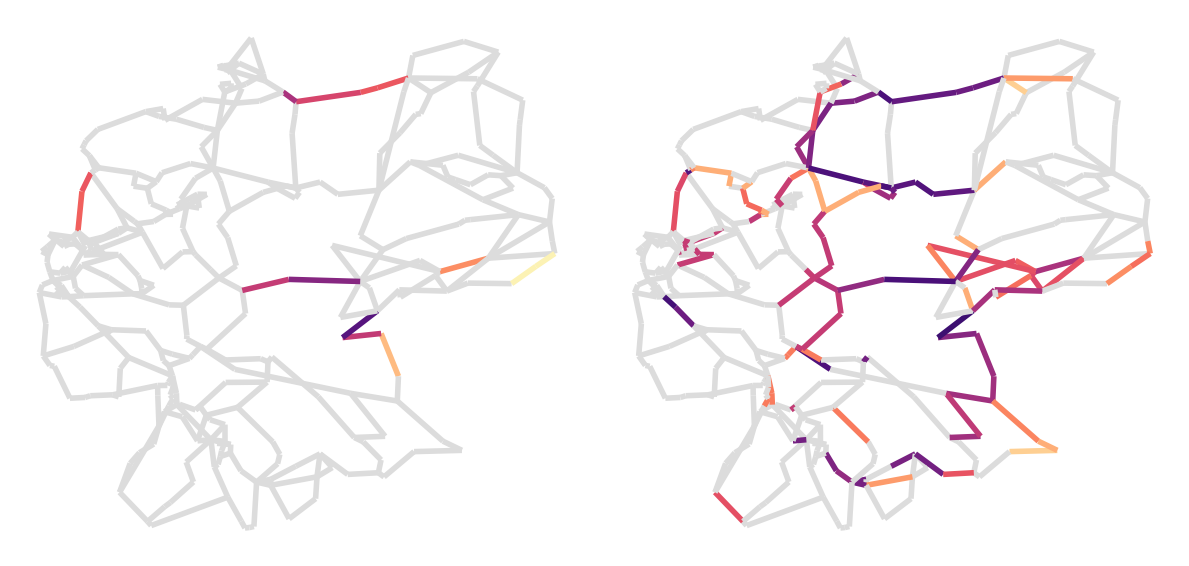

In [50]:
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

f,ax = plt.subplots(1,2,figsize = (15,7))
f.subplots_adjust(hspace = 0.05,wspace = 0.05)


cmap = copy.copy(mpl.cm.get_cmap("magma_r"))
cmap.set_under('gainsboro',1.0)


    
positions = network.buses[["x","y"]]
pos = dict(zip(positions.index,list(zip(positions.x,positions.y))))

likelihood = [likelihood_primary[(u,v)] for u,v in Graph.edges()]

c_H = np.array([np.log10(x) if x>1e-8 else -np.inf for x in likelihood])#PTDF[:,link])])
vmax = 10**(np.max(c_H[np.logical_and(np.logical_and(~np.isnan(c_H),c_H!=-float("inf")),c_H!=1e5)]))
vmin = 10**(np.min(c_H[np.logical_and(~np.isnan(c_H),c_H!=-float("inf"))]))
vmin = np.min([9e-5,vmin])
vmax = np.max([1.0,vmax])
print(vmax)
print(vmin)
nodes = nx.draw_networkx_nodes(Graph, 
                               pos = pos,
                               ax = ax[0],
                               node_color = 'black',
                               node_size = 0)

edges = nx.draw_networkx_edges(Graph, 
                               pos = pos,
                               ax = ax[0], 
                               edge_color = c_H,
                               width = 4,
                               edge_cmap = cmap,
                               edge_vmin = np.log10(vmin),
                               edge_vmax = np.log10(vmax))

ax[0].axis('off')
#ax[0].set_title(years[i],fontsize = 40)
    
#cbar_ax = f.add_axes([0.91, 0.575, 0.007, 0.3])#    
#sm = plt.cm.ScalarMappable(cmap = cmap,norm = mplcolors.LogNorm(vmin = vmin,vmax = vmax)) 
#cb = f.colorbar(sm,cax = cbar_ax)
#cb.ax.tick_params(labelsize = 30, width = 1.0, which = 'both')
#    
#    
#cmap = copy.copy(mpl.cm.get_cmap("viridis_r"))
#cmap.set_under('gainsboro',1.0)
#
    

likelihood = np.array([likelihood_secondary[(u,v)] for u,v in Graph.edges()])

c_H = np.array([np.log10(x) if x>1e-8 else -np.inf for x in likelihood])#PTDF[:,link])])
vmax = 10**(np.max(c_H[np.logical_and(np.logical_and(~np.isnan(c_H),c_H!=-float("inf")),c_H!=1e5)]))
vmin = 10**(np.min(c_H[np.logical_and(~np.isnan(c_H),c_H!=-float("inf"))]))
vmin = np.min([1e-7,vmin])
vmax = np.max([3e-3,vmax])
print(vmin)
print(vmax)
nodes = nx.draw_networkx_nodes(Graph, 
                               pos = pos,
                               ax = ax[1],
                               node_color = 'black',
                               node_size = 0)

edges = nx.draw_networkx_edges(Graph, 
                               pos = pos,
                               ax = ax[1], 
                               edge_color = c_H,
                               width = 4,
                               edge_cmap = cmap,
                               edge_vmin = np.log10(vmin),
                               edge_vmax = np.log10(vmax))

ax[1].axis('off')
        #(datetime.datetime.strptime(str(i+1), "%m").strftime("%b"), fontsize = 24)


#plt.suptitle('Most likely splits - 2014', fontsize = 30)
#plt.savefig('/home/franz/ownCloud/system-split/Results/Figures/Likely_splits_edge_based_Germany_all years.pdf',bbox_inches = 'tight')

plt.show()

## Following is OLD code

In [157]:
import os

import pypsa
import networkx as nx
import numpy as np
import pickle

from tqdm import tqdm

import sys

script_path = os.path.dirname(os.path.realpath('__file__'))

#if not os.path.exists(script_path + '/Results'):
#    os.makedirs(script_path + '/Results')

sys.path.append('power-system-split/power_system_split')
import utils

current_year = 2014#int(sys.argv[1])
current_month = 1#int(sys.argv[2])
number_of_nodes = 306#int(sys.argv[3])


save_path = 'Results/'
load_path = path+'Data/system_split/Data/%i/' % current_year


network = pypsa.Network()
network.import_from_netcdf(load_path + 'elec_s_%i_ec_lv1.0_1H.nc' % number_of_nodes)
network.determine_network_topology()

branches = network.branches()
branches = branches[["bus0", "bus1", "x_pu_eff", "s_nom"]]

G = utils.build_networkx_graph(branches)

current_snapshots = network.snapshots[(network.snapshots.month == current_month) & (network.snapshots.day == 1)]

indices = nx.get_edge_attributes(G, 'line_index')
line_limits = nx.get_edge_attributes(G, 's_nom')

### iterate only over non-bridge edges for now
bridges = list(nx.bridges(nx.Graph(G)))

non_bridges = list(set(list(G.edges())) - set(bridges))

splitting_cascades = {}

for snapshot in tqdm(current_snapshots):

    splitting_cascades[snapshot.strftime('%d_%m_%Y_%H')] = []

    initial_loading = {e: np.sum([network.lines_t.p0.loc[snapshot].loc[index] for index in index_list]) for
                       e, index_list in indices.items()}
    P0 = utils.get_effective_injections(G, initial_loading)

    l_copy = initial_loading.copy()
    for key in l_copy.keys():
        initial_loading[key[::-1]] = initial_loading[key]

    for edge in non_bridges:

        failing_links, system_split = utils.simulate_cascade_PTDF_based_edge_based_reduced(G,
                                                                                           trigger_links=[edge],
                                                                                           line_limits=line_limits,
                                                                                           P0=P0)
        if system_split:
            splitting_cascades[snapshot.strftime('%d_%m_%Y_%H')].append(failing_links)

Importing PyPSA from older version of PyPSA than current version 0.17.1.
Please read the release notes at https://pypsa.org/doc/release_notes.html
carefully to prepare your network for import.

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))


KeyboardInterrupt: 

In [8]:
solution_dict = {}

for key in tqdm(splitting_cascades.keys()):
    timestamp = utils.solution_key_to_pandas_timestamp(key)
    solution_dict[key] = []
    splits = splitting_cascades[key]

    for i, split in enumerate(splits):
        results = utils.evaluate_split_observables(split,
                                                   network,
                                                   timestamp,
                                                   use_pnom=True,
                                                   criterion='load')
        if results['inertia_proxy']:
            solution_dict[key].append(i)
            solution_dict[key].append(results)

  0%|          | 0/24 [00:00<?, ?it/s]INFO:numexpr.utils:Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
INFO:numexpr.utils:NumExpr defaulting to 8 threads.
100%|██████████| 24/24 [00:51<00:00,  2.13s/it]


In [179]:
current_month = 1
co2l = 0.0
s = 'Europe_%i_Co2L%.1f_split_evaluation_' % (current_month, co2l)+ criterion +'_based'
print(s)

Europe_1_Co2L0.0_split_evaluation_load_based


In [182]:
a = [1,2,3]
af = 1
for count,ind in enumerate(a[af:],start = af):
    print(count,ind)

1 2
2 3
